In [27]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install kagglehub

     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     -------------------------------------- 40.1/40.1 kB 963.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ---------------------------------- ----- 61.4/70.6 kB ? eta -:--:--
   ---------------------------------------- 70.6/70.6 kB 958.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/262.5 kB ? eta -:--:--
   --------------------------------------  256.0/262.5 kB 16.4 MB/s eta 0:00:01
   ---------------------------------------- 262.5/262.5 kB 5.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install category_encoders

   ---------------------------------------- 0.0/107.9 kB ? eta -:--:--
   ---------------------------------------- 107.9/107.9 kB 3.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install imbalanced-learn 

   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   -------- ------------------------------- 51.2/236.1 kB 1.3 MB/s eta 0:00:01
   --------------- ------------------------ 92.2/236.1 kB 2.6 MB/s eta 0:00:01
   --------------- ------------------------ 92.2/236.1 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  235.5/23


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install --upgrade category_encoders

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 16.5 MB/s eta 0:00:01
   ---- ----------------------------------- 1.3/11.3 MB 16.7 MB/s eta 0:00:01
   ------- -------------------------------- 2.2/11.3 MB 17.1 MB/s eta 0:00:01
   -------- ------------------------------- 2.3/11.3 MB 16.1 MB/s eta 0:00:01
   -------- ------------------------------- 2.3/11.3 MB 12.4 MB/s eta 0:00:01
   -------- ------------------------------- 2.5/11.3 MB 9.2 MB/s eta 0:00:01
   -------- ------------------------------- 2.5/11.3 MB 8.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.7/11.3 MB 7.6 MB/s eta 0:00:02
   ----------- ---------------------------- 3.2/11.3 MB 7.8 MB/s eta 0:00:02
   ------------ --------------------------- 3.6/11.3 MB 7.9 MB/s eta 0:00:01
   --------------- ------------------------ 4.5/11.3 MB 9.2 MB/s eta 0:00:01
   ------------------- -------------------- 5.7/11.3 MB 10.6 MB/s eta 0:00:01



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date
from scipy.stats import skew
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from category_encoders import LeaveOneOutEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay, average_precision_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import kagglehub
import os
import re
import math
import joblib
from pathlib import Path

# to split the train and test set 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

## Loading dataset from Kaggle

In [10]:
path = kagglehub.dataset_download("chetanmittal033/credit-card-fraud-data")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\chetanmittal033\credit-card-fraud-data\versions\1


In [11]:
credit_df = pd.read_csv(os.path.join(path, "fraudTest.csv"))
credit_df.shape

(555719, 23)

 # DATA UNDERSTANDING

In [9]:
# describe the numeric variables
credit_df.describe()

,sn,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800430e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521420e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635330e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992350e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [10]:
# describe the non-numeric features
credit_df.describe(include = 'object')

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719
unique,226976,693,14,341,471,2,924,849,50,478,910,555719
top,15-12-2020 21:26,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,444 Robert Mews,Birmingham,TX,Film/video editor,23-03-1977,2da90c7d74bd46a0caf3777415b3ebd3
freq,16,1859,56370,11443,12146,304886,1474,2423,40393,4119,2408,1


In [11]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   sn                     555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  float64
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [12]:
credit_df.head(5)

,sn,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,21-06-2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",21-10-1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,21-06-2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,25-07-1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,21-06-2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,06-07-1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [13]:
credit_df.isnull().sum()

sn                       0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [14]:
credit_df.duplicated().sum()

np.int64(0)

**Dataset has neither duplicate rows nor empty data cell**

In [15]:
credit_df.nunique()

sn                       555719
trans_date_trans_time    226976
cc_num                      904
merchant                    693
category                     14
amt                       37256
first                       341
last                        471
gender                        2
street                      924
city                        849
state                        50
zip                         912
lat                         910
long                        910
city_pop                    835
job                         478
dob                         910
trans_num                555719
unix_time                544760
merch_lat                546490
merch_long               551770
is_fraud                      2
dtype: int64

In this step, we transform raw data into meaningful features:
- Extract temporal feature from timestamp (trans_date_trans_time) - a unit of measurement - to capture seasonal and periodic patterns in transactions.  
-> return: day, month, year, hour, minuter, day_of_week, is_weekend (boolean)
- Extract age from dob: feature calculating difference between the transaction year and the year of birth (dob)  
-> return: dob
- Drop some identifiers and redundant attributes:  
-> drop: trans_num, dob, sn, first, last, dob_year, zip

In [12]:
# This step I extract the valuable features from the date time and dob columns 
# Also drop the redundant columns: 'trans_num', 'dob','sn','first','last','zip'
def pre_process_step (df):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], dayfirst=True)
   
    # extract date feature from the timestamp column 
    df['day'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month
    df['year'] = df['trans_date_trans_time'].dt.year
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['minute'] = df['trans_date_trans_time'].dt.minute
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'] >= 5
    df['is_weekend'] = df['is_weekend'].astype(int)

    # extract age from dob column
    df['dob'] = pd.to_datetime(df['dob'], dayfirst=True)
    df['dob_year'] = df['dob'].dt.year
    current_year = date.today().year
    df['age'] = current_year - df['dob_year']

    # drop sn - index
    # drop first + last, which are personal name of card holder
    # drop trans_num column because it is only the transaction id 
    # while it assigned 271685 differences ids for 271685 training example, it does not have any impact on target 
    # drop zip because we already have lat, long for the explicit location
    cols_to_drop = ['trans_num', 'dob','sn','first','last', 'dob_year','zip']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    return df

In [13]:
credit_df_cleaned = pre_process_step (credit_df)
credit_df_cleaned.shape

(555719, 25)

In [18]:
credit_df_cleaned.nunique()

trans_date_trans_time    226976
cc_num                      904
merchant                    693
category                     14
amt                       37256
gender                        2
street                      924
city                        849
state                        50
lat                         910
long                        910
city_pop                    835
job                         478
unix_time                544760
merch_lat                546490
merch_long               551770
is_fraud                      2
day                          31
month                         7
year                          1
hour                         24
minute                       60
day_of_week                   7
is_weekend                    2
age                          81
dtype: int64

In [10]:
numeric_cols = credit_df_cleaned.select_dtypes(include=['number']).columns
len(numeric_cols)

17

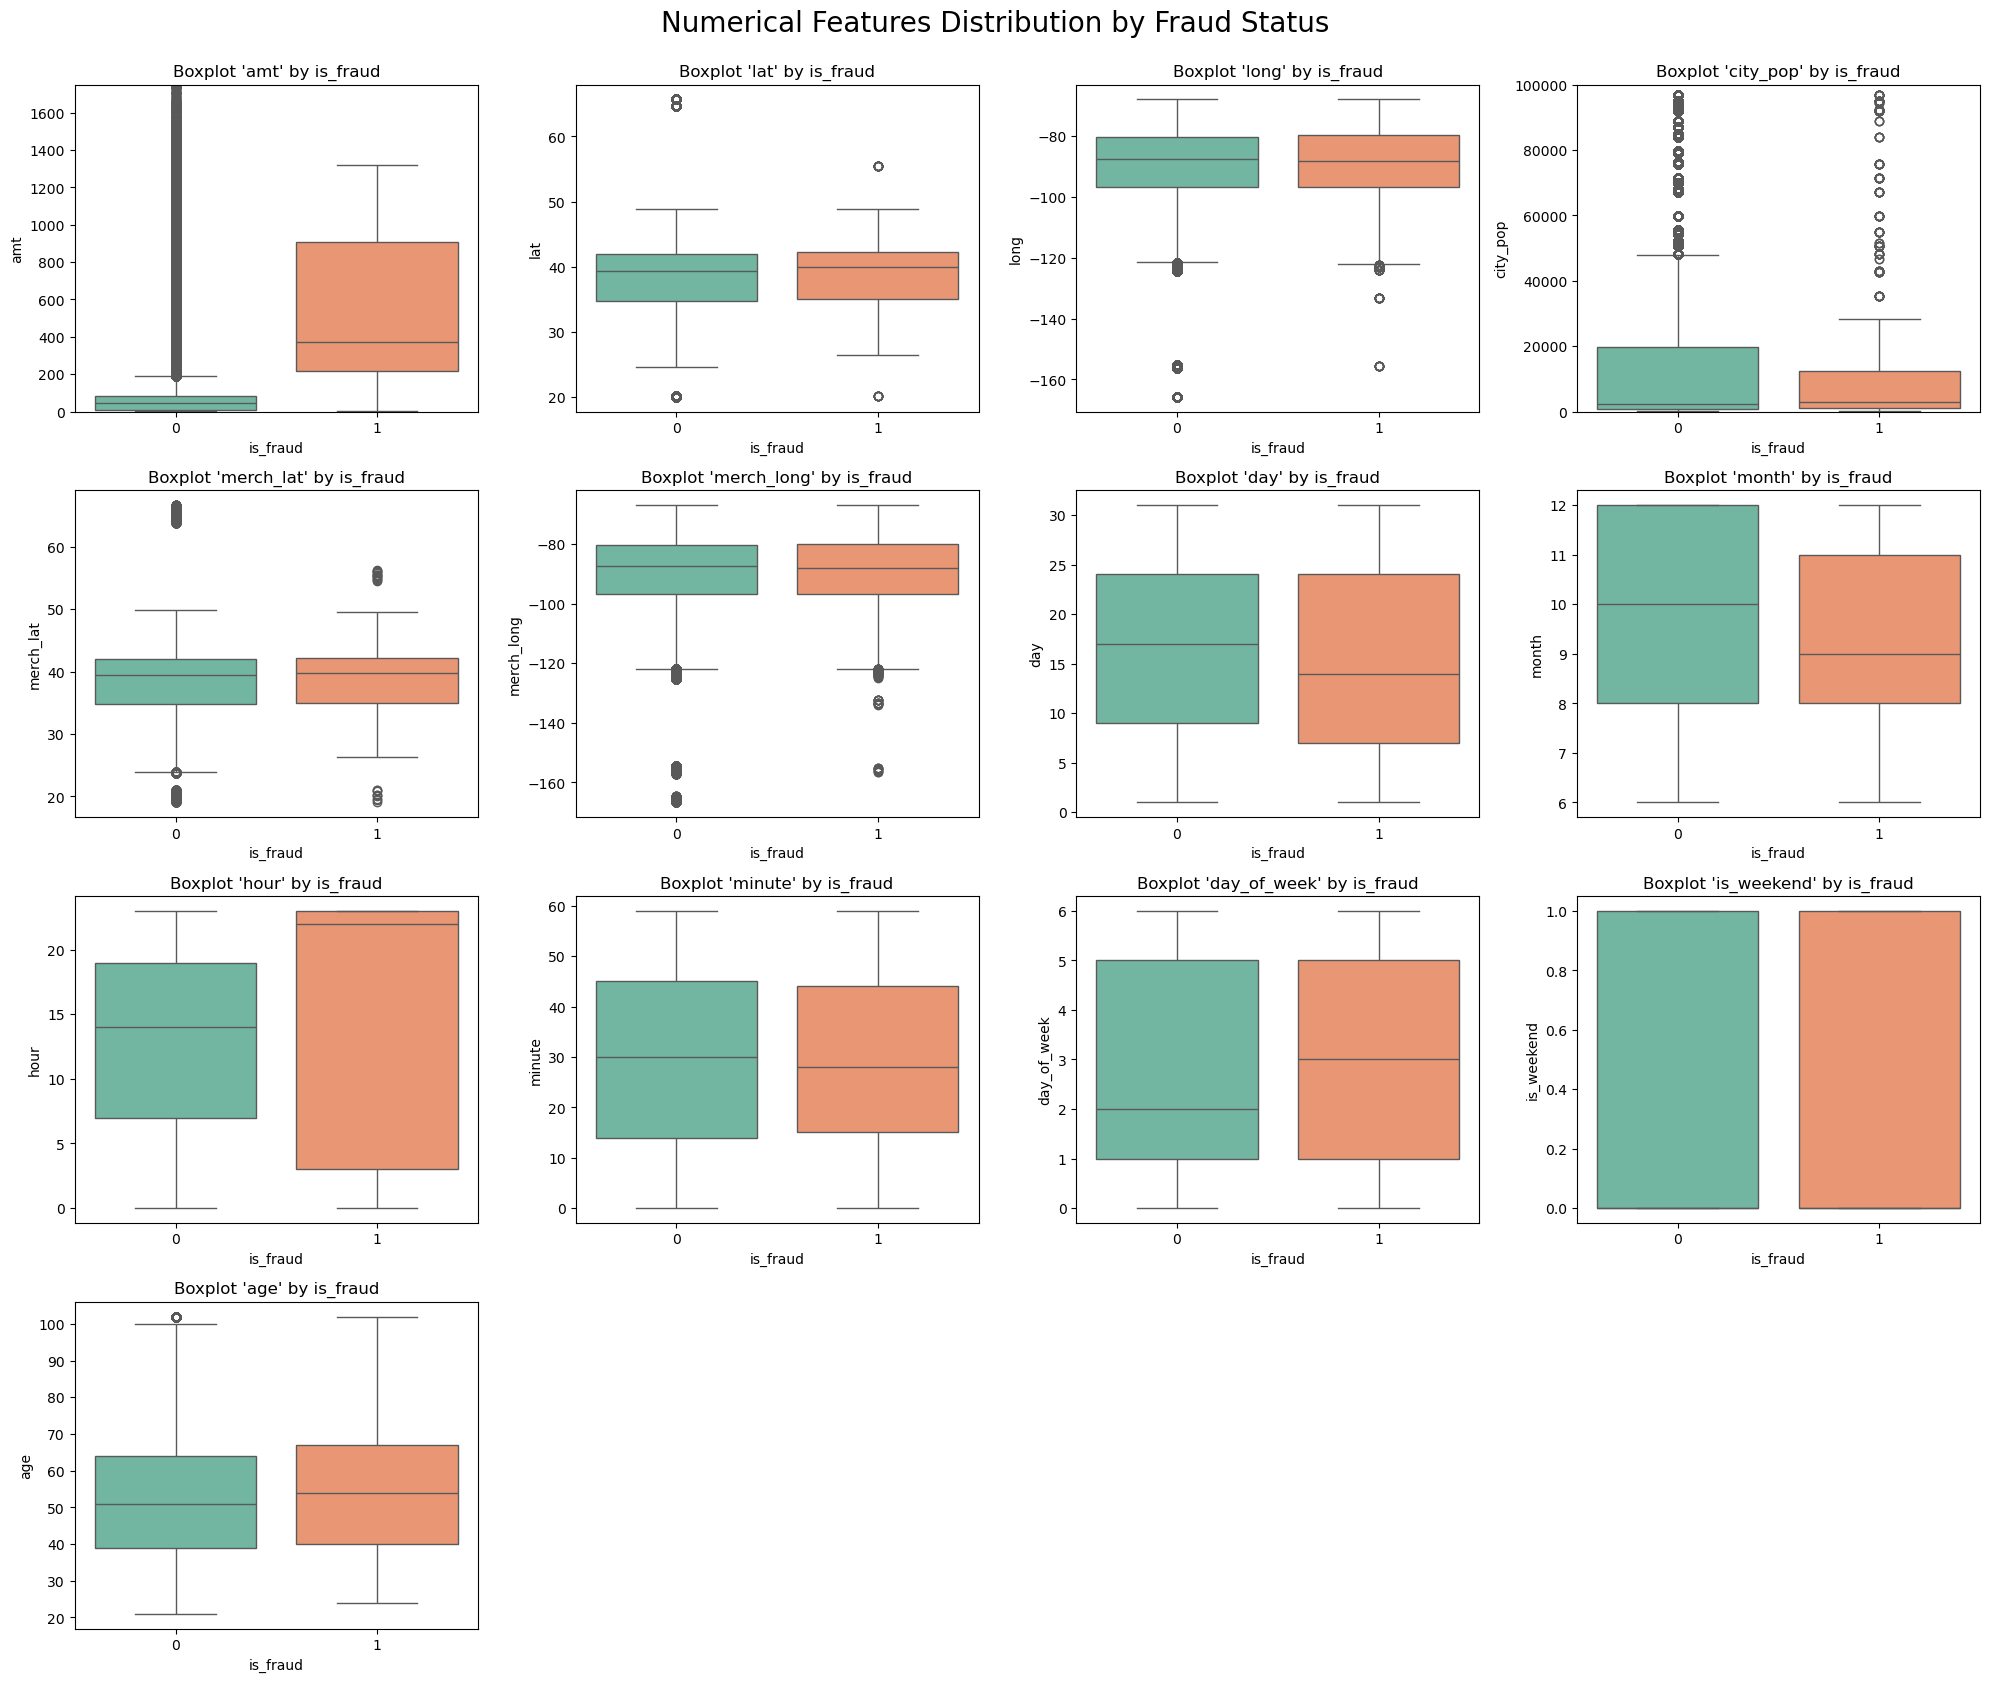

In [11]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes_flat = axes.flatten()

exclude_cols = ['cc_num', 'unix_time', 'year','is_fraud']

plot_index = 0
for cols in numeric_cols:
    if cols in exclude_cols :
        continue

    if plot_index >= len(axes_flat):
        break
    ax = axes_flat[plot_index]
    sns.boxplot(data=credit_df_cleaned, x='is_fraud', y=cols, ax=ax, palette='Set2', hue='is_fraud', legend=False)
    ax.set_title(f"Boxplot '{cols}' by is_fraud")

    if cols == 'amt':
        ax.set_ylim(0, 1750)
    elif cols == 'city_pop':
        ax.set_ylim(0, 100000)
    plot_index += 1
    
for j in range(plot_index, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
fig.suptitle('Numerical Features Distribution by Fraud Status', fontsize=20, y=1.02)
plt.show()

**Observation: Boxplots reveal significant distribution shifts in amt and hour across target classes, suggesting high predictive power for these features.**

**Applied the [Haversine formula](https://distancia.readthedocs.io/en/latest/Haversine.html) to calculate the distance between coordinates (lat-long pairs), converting raw geographic data into a meaningful distance metric.**
$$d = 2r \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$
Newly Engineered Features:
- is_first_txn (boolean): Identifies the first transaction made by an account (cc_num) at a specific merchant.
- is_invalid_latlong (boolean): Flags potential data errors or default/null latitude and longitude values.
- dist_from_prev_txn (float): The Haversine distance between the current and the previous transaction of the same account.
- time_diff_sec (float): The time interval (in seconds) between the current and the previous transaction.
- speed (float): Derived by dividing dist_from_prev_txn by time_diff_sec to detect physically impossible travel speeds.

In [14]:
def calculate_haversine_distance(df, lat1, long1, lat2, long2):
    """
    calculate the distance between Longitude và Latitude of merchant and registered Longitude và Latitude of customer
    using Haversine formula calculates 
    """
    # Earth radius in km
    radius = 6371.0 

    # Convert decimal degrees to radians
    rad_lat1 = np.radians(df[lat1])
    rad_long1 = np.radians(df[long1])
    rad_lat2 = np.radians(df[lat2])
    rad_long2 = np.radians(df[long2])

    # Haversine forula
    delta_lat = rad_lat2 - rad_lat1
    delta_long = rad_long2 - rad_long1

    a = np.sin(delta_lat / 2)**2 + np.cos(rad_lat1) * np.cos(rad_lat2) * np.sin(delta_long / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    distance_km = radius * c
    
    return distance_km

In [15]:
credit_df_cleaned['distance_km'] = calculate_haversine_distance(credit_df_cleaned, lat1='lat', long1='long', lat2='merch_lat', long2='merch_long')
print(credit_df_cleaned[['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']].head())

       lat      long  merch_lat  merch_long  distance_km
0  33.9659  -80.9355  33.986391  -81.200714    24.561462
1  40.3207 -110.4360  39.450498 -109.960431   104.925092
2  40.6729  -73.5365  40.495810  -74.196111    59.080078
3  28.5697  -80.8191  28.812398  -80.883061    27.698567
4  44.2529  -85.0170  44.959148  -85.884734   104.335106


In [23]:
print((credit_df_cleaned[['merch_lat', 'merch_long']] == 0).sum())

merch_lat     0
merch_long    0
dtype: int64


In [16]:
# calculate the distance between the last transaction location (prev_merch_long/lat) and this transaction location (merch_long/lat)
# calculate the time difference between the last transaction --> then calculate speed by distance/time
# group each transaction by each card (cc_num) using group by and shift
# sort the transaction by each card then sort by time
credit_df_cleaned = credit_df_cleaned.sort_values(by=['cc_num', 'unix_time'])

credit_df_cleaned['prev_merch_lat'] = credit_df_cleaned.groupby('cc_num')['merch_lat'].shift(1)
credit_df_cleaned['prev_merch_long'] = credit_df_cleaned.groupby('cc_num')['merch_long'].shift(1)
credit_df_cleaned['prev_unix'] = credit_df_cleaned.groupby('cc_num')['unix_time'].shift(1)

# create a new boolean column to flag the first transaction
credit_df_cleaned['is_first_txn'] = credit_df_cleaned['prev_unix'].isna().astype(int)

# Deal with the error lat,long
credit_df_cleaned['is_invalid_latlong'] = (
    (credit_df_cleaned['merch_lat'] == 0) | (credit_df_cleaned['merch_long'] == 0) |
    (credit_df_cleaned['prev_merch_lat'] == 0) | (credit_df_cleaned['prev_merch_long'] == 0)
).astype(int)

# Calculate the distance from last merch location
credit_df_cleaned['dist_from_prev_txn'] = calculate_haversine_distance(
    credit_df_cleaned, 
    lat1 ='merch_lat', long1='merch_long', 
    lat2='prev_merch_lat', long2='prev_merch_long'
)

# Calculate the time differenct from the last transaction
credit_df_cleaned['time_diff_sec'] = credit_df_cleaned['unix_time'] - credit_df_cleaned['prev_unix']

# Calculate speed 
credit_df_cleaned['speed'] = 0.0
mask_normal = (credit_df_cleaned['time_diff_sec'] > 0) & (credit_df_cleaned['is_invalid_latlong'] == 0)
credit_df_cleaned.loc[mask_normal, 'speed'] = (credit_df_cleaned['dist_from_prev_txn'] / credit_df_cleaned['time_diff_sec']) * 3600
# Case: time diff = 0 & dist from prev > 0 & is_invalid_latlong == 0 --> instant moving
mask_teleport = (credit_df_cleaned['time_diff_sec'] == 0) & (credit_df_cleaned['dist_from_prev_txn'] > 0) & (credit_df_cleaned['is_invalid_latlong'] == 0)
credit_df_cleaned.loc[mask_teleport, 'speed'] = 9999.0

# Fill the NaN data points with 0 
credit_df_cleaned[['time_diff_sec', 'speed','dist_from_prev_txn']] = credit_df_cleaned[['time_diff_sec', 'speed','dist_from_prev_txn']].fillna(0)

# drop the redundant column
credit_df_cleaned = credit_df_cleaned.drop(columns=['prev_merch_lat', 'prev_merch_long','prev_unix'])

print(credit_df_cleaned[['cc_num', 'unix_time', 'time_diff_sec', 'dist_from_prev_txn', 'speed']].head(10))

             cc_num   unix_time  time_diff_sec  dist_from_prev_txn      speed
157    6.041621e+10  1371819942            0.0            0.000000   0.000000
741    6.041621e+10  1371831936        11994.0           84.573286  25.384678
3047   6.041621e+10  1371887913        55977.0          210.358816  13.528623
4351   6.041621e+10  1371915151        27238.0           58.123267   7.682053
7695   6.041621e+10  1371990534        75383.0           75.083329   3.585689
8059   6.041621e+10  1371997488         6954.0           96.804487  50.114489
8518   6.041621e+10  1372005580         8092.0          152.552543  67.868161
9059   6.041621e+10  1372014425         8845.0          183.644650  74.745137
9771   6.041621e+10  1372027557        13132.0          156.464883  42.893206
10266  6.041621e+10  1372047737        20180.0           38.678220   6.899980


(0.0, 1500.0)

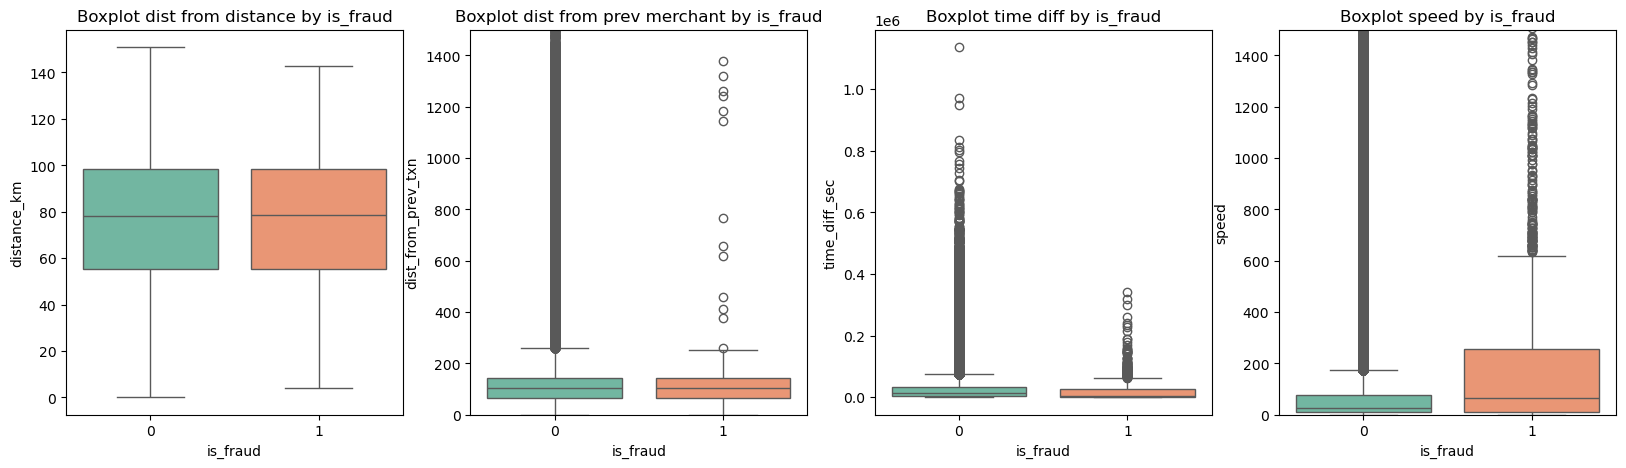

In [25]:
fig, axes = plt.subplots(1,4, figsize=(20, 5))

sns.boxplot(data=credit_df_cleaned, x='is_fraud', y='distance_km', ax=axes[0], palette='Set2', hue='is_fraud', legend=False)
axes[0].set_title(f"Boxplot dist from distance by is_fraud")

sns.boxplot(data=credit_df_cleaned, x='is_fraud', y='dist_from_prev_txn', ax=axes[1], palette='Set2', hue='is_fraud', legend=False)
axes[1].set_title(f"Boxplot dist from prev merchant by is_fraud")
axes[1].set_ylim(0, 1500)

sns.boxplot(data=credit_df_cleaned, x='is_fraud', y='time_diff_sec', ax=axes[2], palette='Set2', hue='is_fraud', legend=False)
axes[2].set_title(f"Boxplot time diff by is_fraud")
#axes[2].set_ylim(0, 0.02)

sns.boxplot(data=credit_df_cleaned, x='is_fraud', y='speed', ax=axes[3], palette='Set2', hue='is_fraud', legend=False)
axes[3].set_title(f"Boxplot speed by is_fraud")
axes[3].set_ylim(0, 1500)

**From the plot, speed is predicted to become the meaningful predictor**

To capture spending behavior, the current transaction amount is compared against historical spending patterns. This is achieved through two main approaches:
* Global Historical Comparison: Compare with entire historical transactions
  * amt_vs_historical_ratio (float): The ratio of the current transaction amount to the average of all previous transactions for that account.
* Time-Windowed (Rolling) Statistics:
  * trans_count_24h (int): Number of transactions within the last 24 hours.
  * amt_perc_of_24h (float): Ratio of the current amount to the average spending in the last 24 hours.
  * avg_amt_7d / avg_amt_30d (float): Average spending over the last 7 and 30 days, respectively.
  * ratio_vs_7d / ratio_vs_30d (float): Ratio of the current amount to the 7-day and 30-day moving averages.

**Note: To prevent Data Leakage, all rolling and window calculations (using rolling and window packages) are configured to exclude the current transaction. This ensures that the model does not "peek" at the target value it is trying to predict during the feature engineering phase.**

In [17]:
# calculate the ratio between this transaction amount and the mean of previous transaction amount (whole historical transactions)
# excluding this transaction
# sort dataset by unix time
credit_df_cleaned = credit_df_cleaned.sort_values(['cc_num', 'unix_time'])
    
# 2. credit_df_cleaned accumulated mean for each cc_nums
# cumsum() accumulated summary, cumcount() accumulated quantity including this transaction    
credit_df_cleaned['cum_amt'] = credit_df_cleaned.groupby('cc_num')['amt'].cumsum()
credit_df_cleaned['cum_count'] = credit_df_cleaned.groupby('cc_num').cumcount() + 1
    
# calculate expanding mean for the historical spending amount including the current transaction
credit_df_cleaned['avg_amt_so_far'] = credit_df_cleaned['cum_amt'] / credit_df_cleaned['cum_count']
    
# 4. calculate expanding mean for the historical spending amount excluding the current transaction by shifting 1 rows
credit_df_cleaned['avg_amt_historical'] = credit_df_cleaned.groupby('cc_num')['avg_amt_so_far'].shift(1)
    
# 5. ratio of this transaction compared to historical accumulated average 
credit_df_cleaned['amt_vs_historical_ratio'] = credit_df_cleaned['amt'] / credit_df_cleaned['avg_amt_historical']
    
credit_df_cleaned = credit_df_cleaned.drop(columns=['cum_amt', 'cum_count', 'avg_amt_so_far', 'avg_amt_historical' ])
    
# fill NaN value of first transaction of each customer
credit_df_cleaned['amt_vs_historical_ratio'] = credit_df_cleaned['amt_vs_historical_ratio'].fillna(1)

In [18]:
# calculate the total number of transaction + spending in previous 24h exluding current one
# calculate the average of previous transaction within 7 days/30 days forward - excluding current transaction 
# --> compare the current transaction with the total spending in previous 24h 
# ratio between this transaction amount and the previous 7 days/30 days average transaction amount
# using window + closed to exluding the current transactions
df_clean = credit_df_cleaned.sort_values(['cc_num', 'trans_date_trans_time'])
df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])
df_clean = df_clean.set_index('trans_date_trans_time')

# 2. Create group by
gb = df_clean.groupby('cc_num')['amt']

# 3. Calculate the varibled relating in 24h
rolling_24h = gb.rolling(window='24h', closed='left')
df_clean['trans_count_24h'] = rolling_24h.count().reset_index(level=0, drop=True)
df_clean['total_amt_24h'] = rolling_24h.sum().reset_index(level=0, drop=True)

# 4. Calculate Average 7d và 30d
df_clean['avg_amt_7d'] = gb.rolling(window='7D', closed='left').mean().reset_index(level=0, drop=True)
df_clean['avg_amt_30d'] = gb.rolling(window='30D', closed='left').mean().reset_index(level=0, drop=True)

# 5. Calculate ratios
df_clean['amt_perc_of_24h'] = df_clean['amt'] / (df_clean['total_amt_24h'].replace(0, np.nan))
df_clean['ratio_vs_7d'] = df_clean['amt'] / (df_clean['avg_amt_7d'].replace(0, np.nan))
df_clean['ratio_vs_30d'] = df_clean['amt'] / (df_clean['avg_amt_30d'].replace(0, np.nan))

# 6. Fill NaN 
cols_to_fix = ['trans_count_24h', 'total_amt_24h', 'avg_amt_7d', 'avg_amt_30d', 'amt_perc_of_24h', 'ratio_vs_7d', 'ratio_vs_30d']
df_clean[cols_to_fix] = df_clean[cols_to_fix].fillna(0)

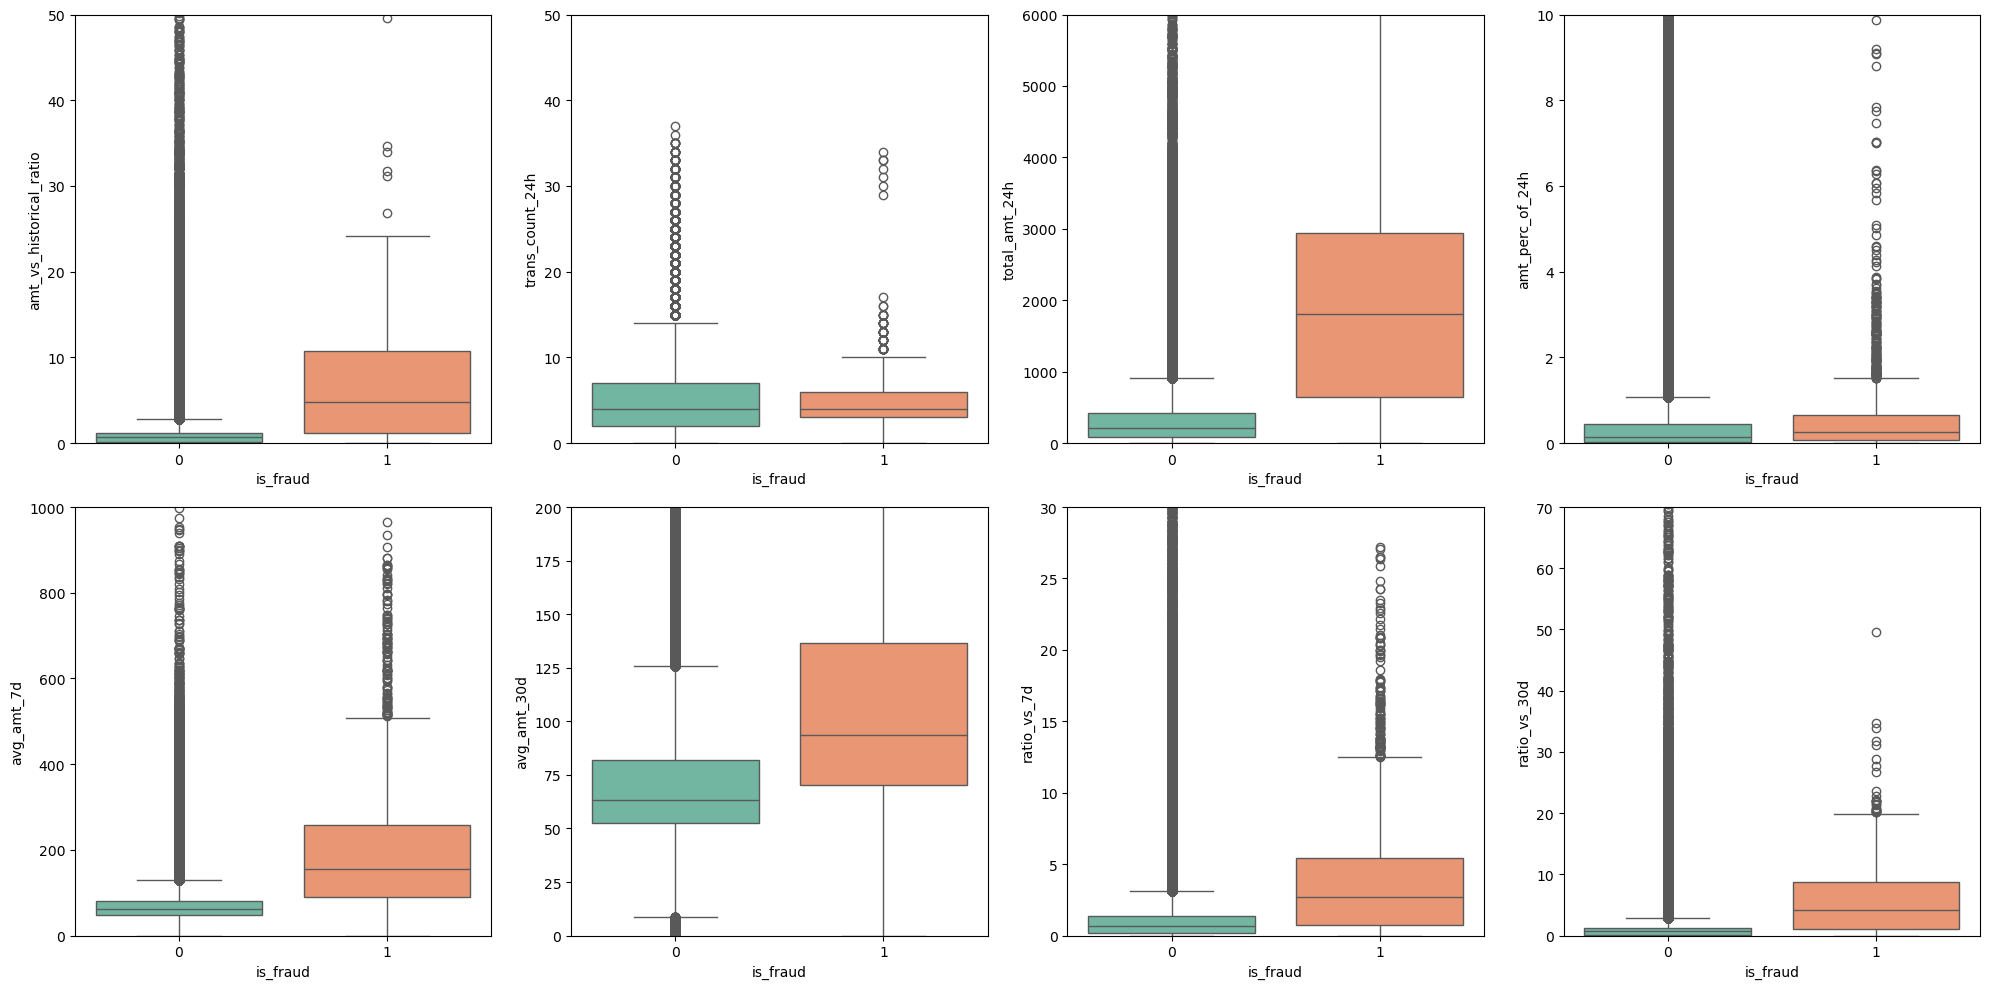

In [28]:
fig, axes = plt.subplots(2,4, figsize=(20, 10))
axes_flat = axes.flatten()

sns.boxplot(data=df_clean, x='is_fraud', y='amt_vs_historical_ratio', ax=axes_flat[0], palette='Set2', hue='is_fraud', legend=False)
axes_flat[0].set_ylim(0, 50)

sns.boxplot(data=df_clean, x='is_fraud', y='trans_count_24h', ax=axes_flat[1], palette='Set2', hue='is_fraud', legend=False)
axes_flat[1].set_ylim(0, 50)

sns.boxplot(data=df_clean, x='is_fraud', y='total_amt_24h', ax=axes_flat[2], palette='Set2', hue='is_fraud', legend=False)
axes_flat[2].set_ylim(0, 6000)

sns.boxplot(data=df_clean, x='is_fraud', y='amt_perc_of_24h', ax=axes_flat[3], palette='Set2', hue='is_fraud', legend=False)
axes_flat[3].set_ylim(0, 10)

sns.boxplot(data=df_clean, x='is_fraud', y='avg_amt_7d', ax=axes_flat[4], palette='Set2', hue='is_fraud', legend=False)
axes_flat[4].set_ylim(0, 1000)

sns.boxplot(data=df_clean, x='is_fraud', y='avg_amt_30d', ax=axes_flat[5], palette='Set2', hue='is_fraud', legend=False)
axes_flat[5].set_ylim(0, 200)

sns.boxplot(data=df_clean, x='is_fraud', y='ratio_vs_7d', ax=axes_flat[6], palette='Set2', hue='is_fraud', legend=False)
axes_flat[6].set_ylim(0, 30)

sns.boxplot(data=df_clean, x='is_fraud', y='ratio_vs_30d', ax=axes_flat[7], palette='Set2', hue='is_fraud', legend=False)
axes_flat[7].set_ylim(0, 70)

plt.tight_layout()
plt.show()

**Most of newly features indicate their powder by observing the different between two boxplots for two fraud and legitimate class**

## Categorical Feature Engineering & Encoding Strategy  
This stage focuses on discovering the categorical structure of the dataset and preparing it for model compatibility.

In [29]:
merchant_locations = df_clean.groupby('merchant')[['merch_lat', 'merch_long']].nunique()
merchant_locations

,merch_lat,merch_long
merchant,,
fraud_Abbott-Rogahn,803,803
fraud_Abbott-Steuber,766,766
fraud_Abernathy and Sons,762,762
fraud_Abshire PLC,838,838
"fraud_Adams, Kovacek and Kuhlman",414,414
...,...,...
fraud_Zemlak Group,591,591
"fraud_Zemlak, Tillman and Cremin",734,734
fraud_Ziemann-Waters,743,743


In [30]:
all_start_with_fraud = df_clean['merchant'].str.startswith('fraud_').all()
all_start_with_fraud

np.True_

In [17]:
df_fraud = df_clean[df_clean['is_fraud'] == 1]
df_safe = df_clean[df_clean['is_fraud'] == 0]
def cal_outliers_not_fraud(df, column):
    if (column in df.columns) :        
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75) 
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        return outliers
    else:
        print(f"column '{column}' is not in data frame")
        return None

In [18]:
d_num_cols = df_safe.select_dtypes(include=['number']).columns

In [19]:
outlier_rates_2 = {}    

for col in d_num_cols:
    outliers_2 = cal_outliers_not_fraud(df_clean, col)
    
    if outliers_2 is not None:
        rate = (len(outliers_2) / len(df_clean)) * 100
        outlier_rates_2[col] = f"{rate:.2f}%"

status_df_2 = pd.DataFrame.from_dict(outlier_rates_2, orient='index', columns=['Outlier Rate'])
print(status_df_2)

                        Outlier Rate
cc_num                         9.17%
amt                            5.00%
lat                            0.35%
long                           3.80%
city_pop                      18.74%
unix_time                      0.00%
merch_lat                      0.38%
merch_long                     3.23%
is_fraud                       0.39%
day                            0.00%
month                          0.00%
year                           0.00%
hour                           0.00%
minute                         0.00%
day_of_week                    0.00%
is_weekend                     0.00%
age                            0.04%
distance_km                    0.00%
is_first_txn                   0.16%
is_invalid_latlong             0.00%
dist_from_prev_txn             1.71%
time_diff_sec                  7.93%
speed                         13.02%
amt_vs_historical_ratio        4.77%
trans_count_24h                2.12%
total_amt_24h                  6.24%
a

In [ ]:
outlier_dfs_dict = {} 
outlier_rates = {}    

for col in d_num_cols:
    outliers = cal_outliers_not_fraud(df_safe, col)
    
    if outliers is not None:
        outlier_dfs_dict[col] = outliers
        
        # 2. Calculate the outlier percentage %
        rate = (len(outliers) / len(df_safe)) * 100
        outlier_rates[col] = f"{rate:.2f}%"

status_df = pd.DataFrame.from_dict(outlier_rates, orient='index', columns=['Outlier Rate'])
print(status_df)

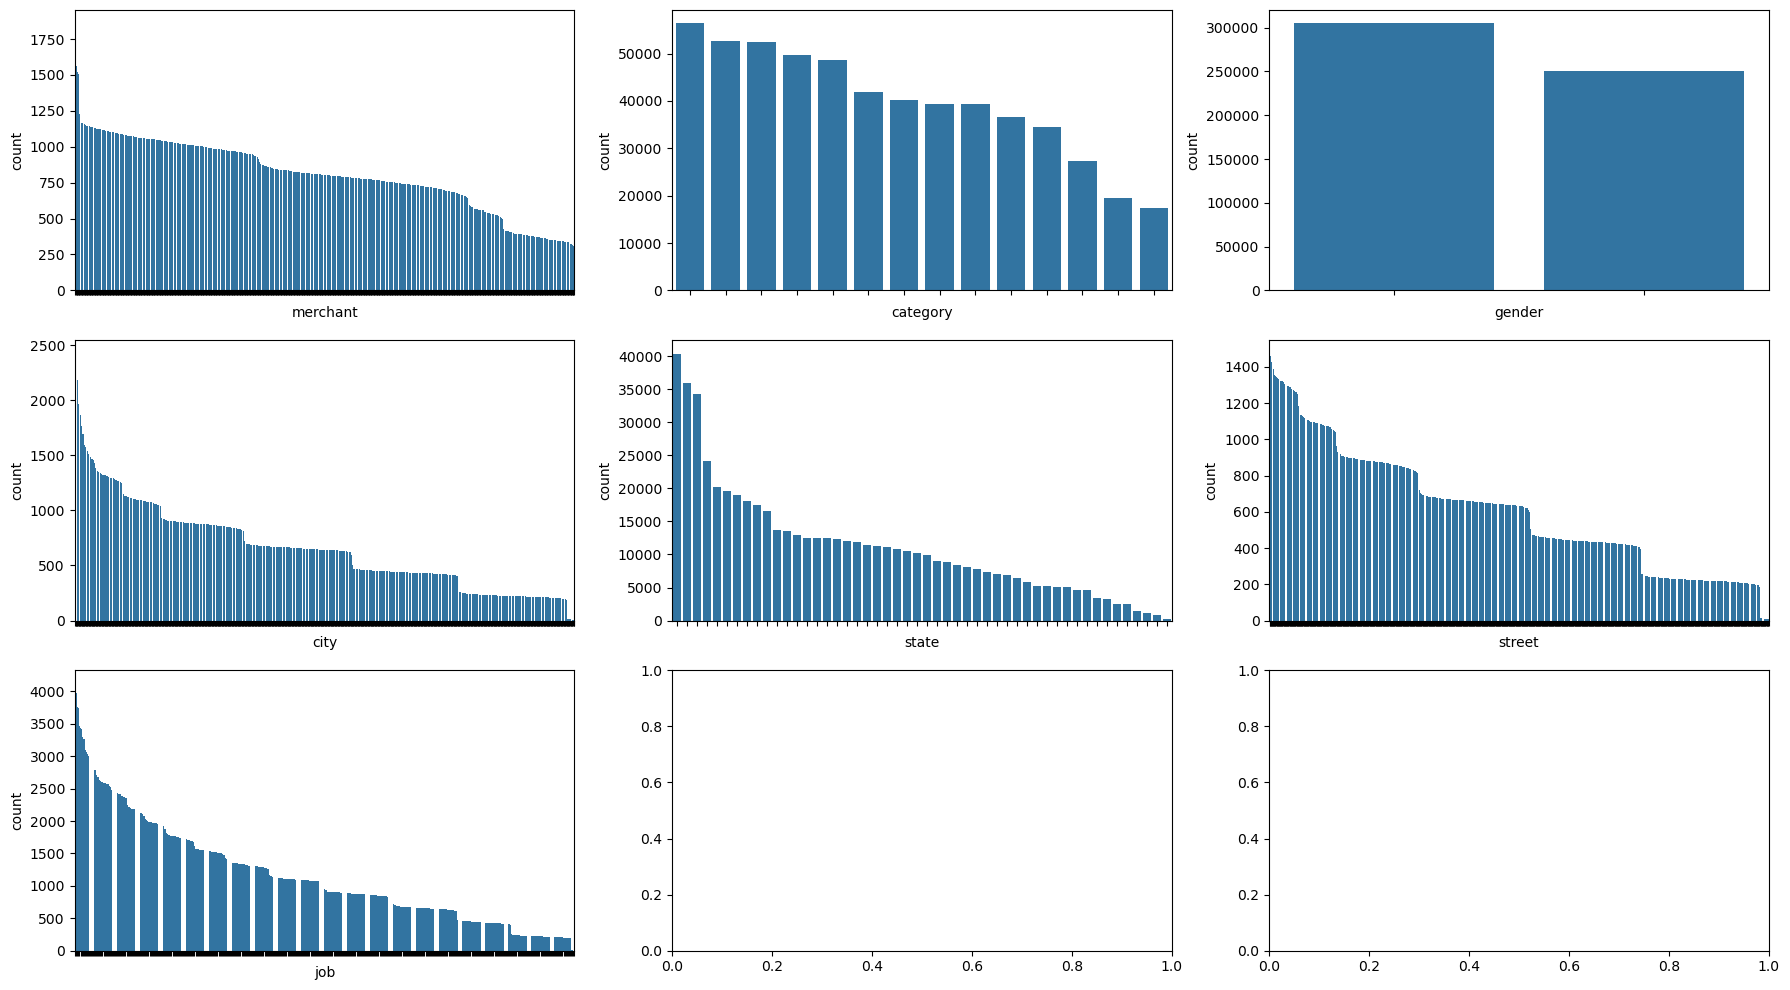

In [35]:
cat_cols = ['merchant', 'category','gender', 'city','state', 'street','job'] 

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_clean, x=col, ax=axes_flat[i], 
                  order=df_clean[col].value_counts().index) 
    axes_flat[i].set_xticklabels([])
    
plt.tight_layout()
plt.show()

High-cardinality features: Features (merchant, city, state, street and job) contain a large number of unique categories, requiring efficient encoding to avoid the "curse of dimensionality.

In [13]:
def calRate (column):
    if (column in df_clean.columns) :
        summary = df_clean.groupby(column)['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
        summary.columns = ['Category', 'Total', 'Fraud_Count', 'Fraud_Rate']
        summary = summary.sort_values(by='Fraud_Rate', ascending=False)
        return summary 
    else:
        print(f"column '{column}' is not in data frame")
        return None

In [37]:
merchants_rate = calRate('merchant')
merchants_rate

,Category,Total,Fraud_Count,Fraud_Rate
528,"fraud_Romaguera, Cruickshank and Greenholt",828,18,0.021739
386,fraud_Lemke-Gutmann,837,18,0.021505
443,"fraud_Mosciski, Ziemann and Farrell",870,18,0.020690
238,"fraud_Heathcote, Yost and Kertzmann",830,17,0.020482
523,"fraud_Rodriguez, Yost and Jenkins",501,10,0.019960
...,...,...,...,...
573,"fraud_Schumm, McLaughlin and Carter",794,0,0.000000
574,fraud_Schuppe LLC,815,0,0.000000
110,"fraud_Cremin, Hamill and Reichel",659,0,0.000000
578,fraud_Shields Inc,369,0,0.000000


C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\3642336672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_merchants.values, y=top_merchants.index, ax=axes[0], palette='Reds_r')
C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\3642336672.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_merchants.values, y=bottom_merchants.index, ax=axes[1], palette='Blues_r')


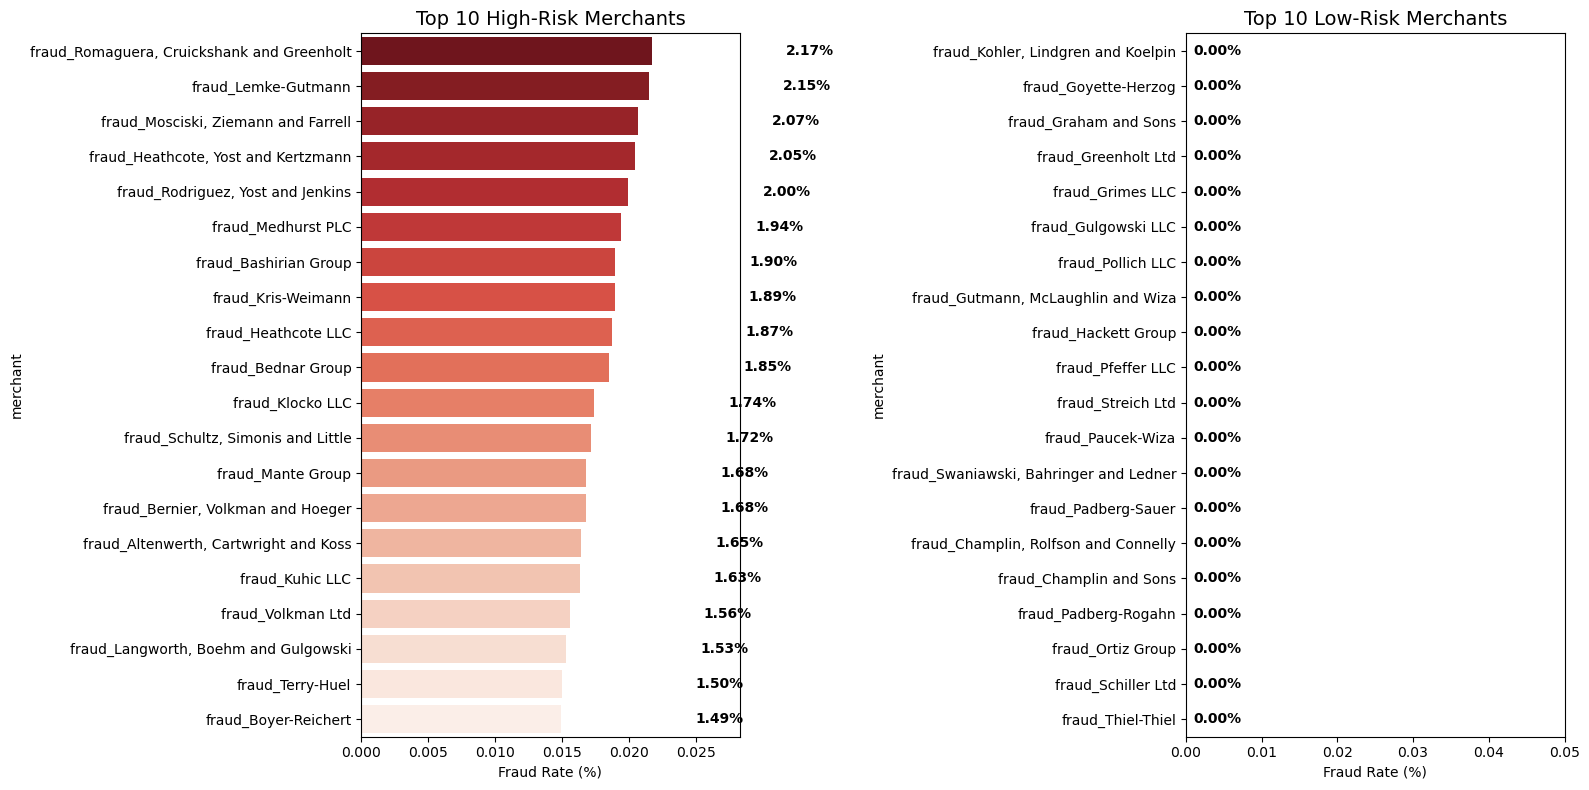

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 

# --- Plot 1: TOP 10 highest ---
top_merchants = df_clean.groupby('merchant')['is_fraud'].mean().sort_values(ascending=False).head(20)

sns.barplot(x=top_merchants.values, y=top_merchants.index, ax=axes[0], palette='Reds_r')

for i, v in enumerate(top_merchants.values):
    axes[0].text(v + 0.01, i, f'{v:.2%}', va='center', fontweight='bold')

axes[0].set_title('Top 10 High-Risk Merchants', fontsize=14)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_xlim(0, max(top_merchants.values) * 1.3) # Tạo khoảng trống cho chữ

# --- Plot 2: TOP 10 lowest ---
bottom_merchants = df_clean.groupby('merchant')['is_fraud'].mean().sort_values(ascending=True).head(20)

sns.barplot(x=bottom_merchants.values, y=bottom_merchants.index, ax=axes[1], palette='Blues_r')

for i, v in enumerate(bottom_merchants.values):
    axes[1].text(v + 0.001, i, f'{v:.2%}', va='center', fontweight='bold')

axes[1].set_title('Top 10 Low-Risk Merchants', fontsize=14)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_xlim(0, max(bottom_merchants.values) + 0.05) 

plt.tight_layout()
plt.show()

**Observation:** The merchant feature show a clear variance in fraud rates but contains 361 unique values.
- One-Hot Encoding Issues: Creating 360+ new columns would cause a computational bottleneck and high dimensionality.
- Target Encoding Risks: While effective, Target Encoding can introduce Data Leakage by incorporating target-related information directly into the feature, potentially leading to overfitting.
- Solution: To extract the merchant's risk profile without these drawbacks, a Derived Feature (e.g., grouping by fraud risk tiers) is implemented to reduce high cardinality while maintaining model integrity.

In [39]:
categories_rate = calRate('category')
categories_rate

,Category,Total,Fraud_Count,Fraud_Rate
11,shopping_net,41779,506,0.012111
8,misc_net,27367,267,0.009756
4,grocery_pos,52553,485,0.009229
12,shopping_pos,49791,213,0.004278
2,gas_transport,56370,154,0.002732
13,travel,17449,40,0.002292
3,grocery_net,19426,41,0.002111
9,misc_pos,34574,72,0.002082
10,personal_care,39327,70,0.001780
0,entertainment,40104,59,0.001471


C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\2887808290.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


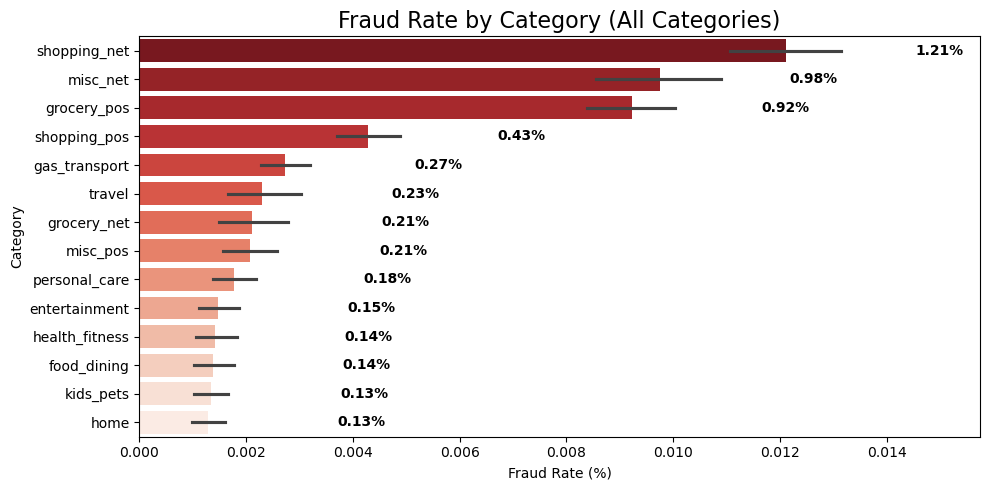

In [40]:
# 1. Increase height (figsize) to fit all categories comfortably
plt.figure(figsize=(10, 5)) 

# 2. Get ALL category names sorted by fraud rate
all_categories_sorted = df_clean.groupby('category')['is_fraud'].mean().sort_values(ascending=False).index

# 3. Use the full credit_df_cleaned to allow Seaborn to calculate Error Bars (CI)
ax = sns.barplot(
    data=df_clean, 
    x='is_fraud', 
    y='category', 
    order=all_categories_sorted, 
    palette='Reds_r', 
    errorbar='ci'
)

# 4. Calculate means and a dynamic offset for labels
means = df_clean.groupby('category')['is_fraud'].mean().loc[all_categories_sorted]
offset = means.max() * 0.2 # Space to ensure text is past the error bar whiskers

for i, v in enumerate(means):
    # Add text label next to the bar
    ax.text(v + offset, i, f'{v:.2%}', va='center', ha='left', fontweight='bold')

# 5. Expand the X-axis limit so labels don't touch the border
ax.set_xlim(0, means.max() * 1.3) 

plt.title('Fraud Rate by Category (All Categories)', fontsize=16)
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Observation:** Category demonstrate the specific gap between the highest fraud rate category the lowest and have the acceptable number of value. Therefor, one hot coding will be applied

In [41]:
genders_rate = calRate('gender')
genders_rate

,Category,Total,Fraud_Count,Fraud_Rate
1,M,250833,981,0.003911
0,F,304886,1164,0.003818


<Figure size 500x500 with 0 Axes>

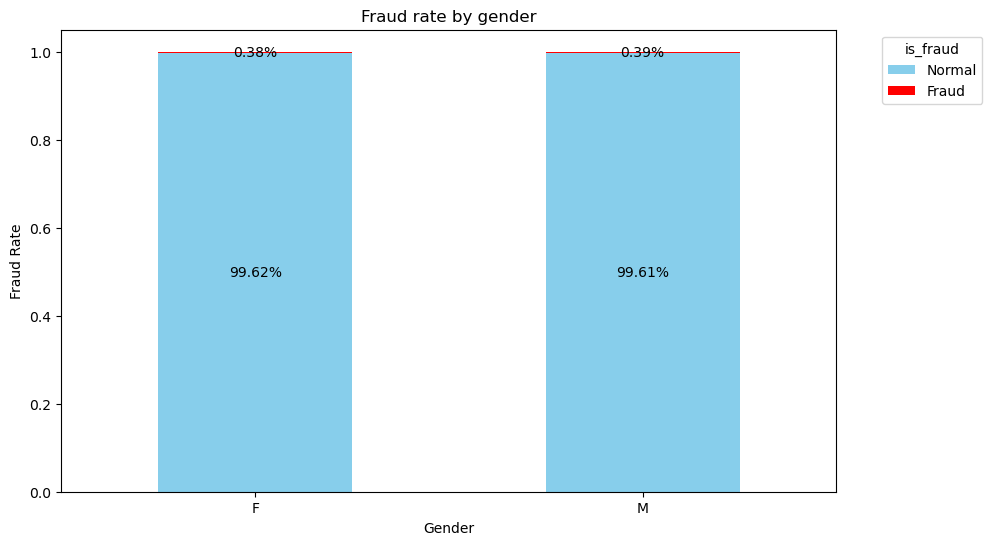

In [42]:
# statical table: Gender, is_fraud
gender_fraud = pd.crosstab(df_clean['gender'], df_clean['is_fraud'])
gender_fraud.columns = ['Normal', 'Fraud']

# convert into the same 100% stack data
gender_fraud_pct = gender_fraud.div(gender_fraud.sum(axis=1), axis=0)
plt.figure(figsize=(5, 5)) 
ax = gender_fraud_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'red'])

plt.title('Fraud rate by gender')
plt.xlabel('Gender')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=0)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: 
        ax.annotate(f'{height:.2%}', (x + width/2, y + height/2), ha='center', va='center')

plt.legend(title='is_fraud', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Observation:** The plot reveals no significant difference in fraud_rate between genders. Given its low predictive power, this feature will be removed to reduce model complexity and prevent overfitting.

In [43]:
Streets_rate = calRate('street')
Streets_rate

,Category,Total,Fraud_Count,Fraud_Rate
733,77686 Donald Bridge Apt. 711,10,10,1.0
899,9652 Ford Ford Apt. 566,12,12,1.0
75,08469 Trujillo Forge,12,12,1.0
851,914 Nancy Square,11,11,1.0
506,537 Brian Island,9,9,1.0
...,...,...,...,...
117,133 Alyssa Plains,680,0,0.0
116,13299 Patrick Terrace,702,0,0.0
431,4483 Sharp Ferry Apt. 468,237,0,0.0
432,44864 Melton Vista Suite 310,220,0,0.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\1038114681.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_data, x='is_fraud', y='street', ax=axes[0],
C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\1038114681.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_data, x='is_fraud', y='street', ax=axes[1],


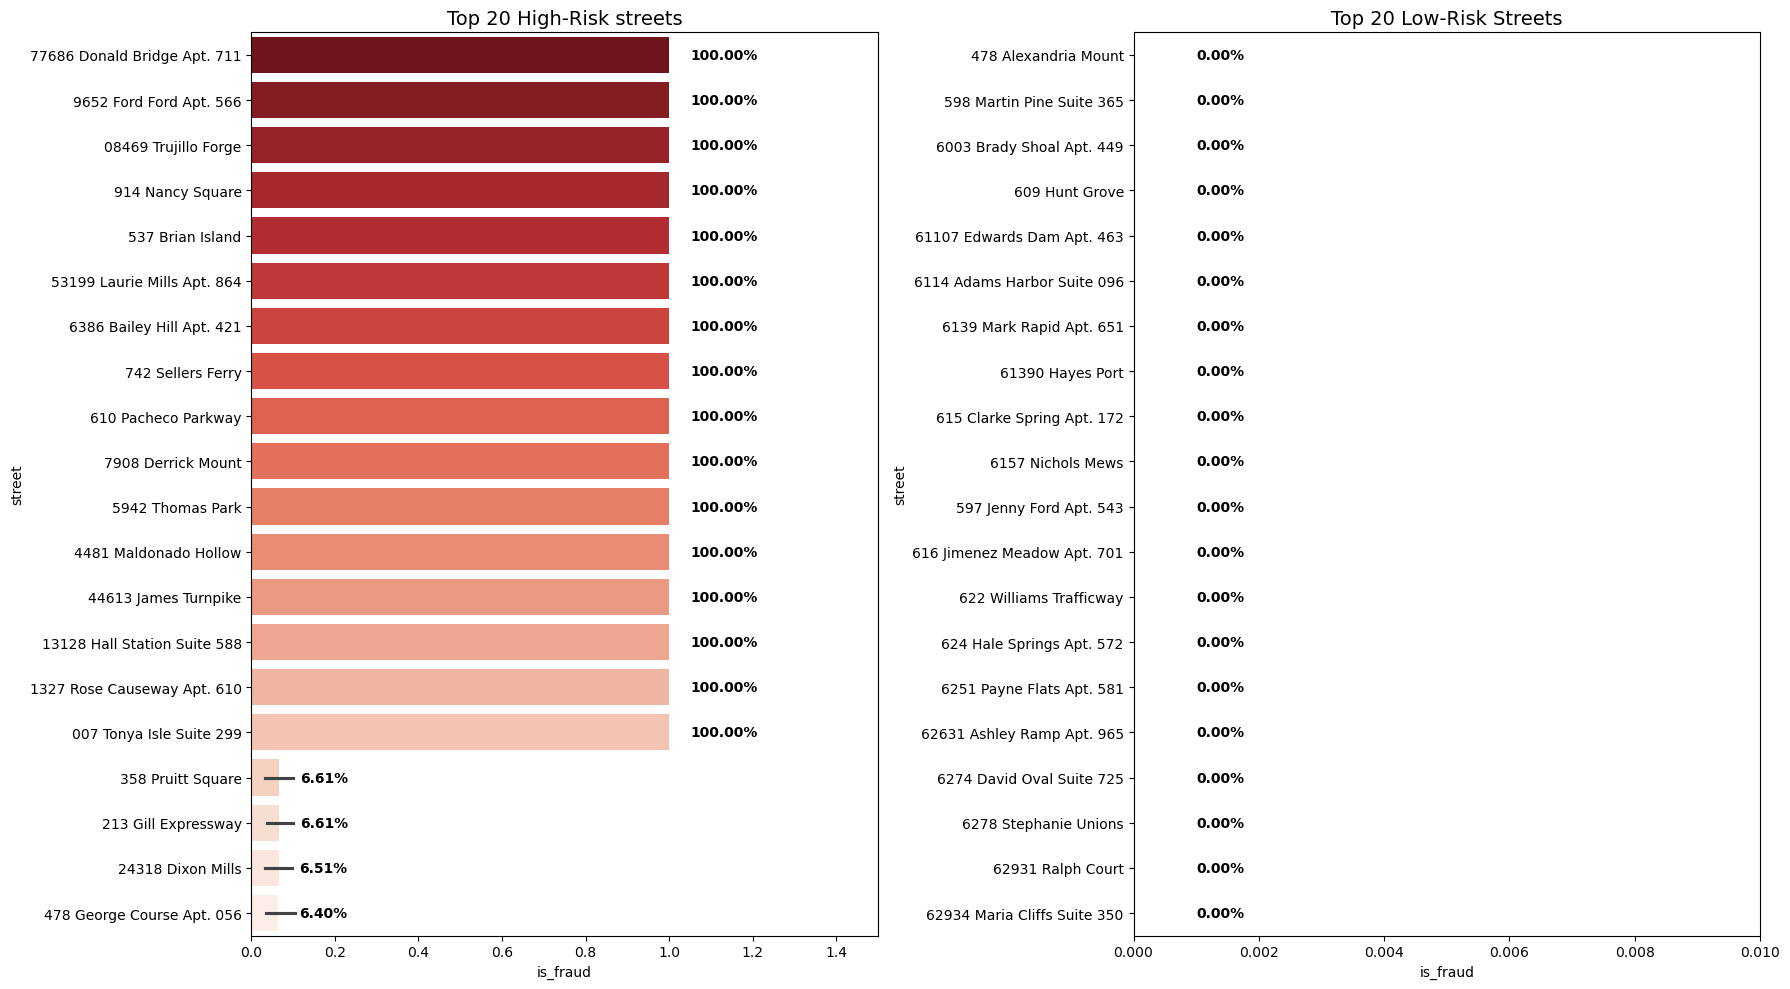

In [44]:
# 1. Setup figure with enough height for 20 items per side
fig, axes = plt.subplots(1, 2, figsize=(18, 10)) 

# --- PLOT 1: TOP 20 highest ---
# Get the order/names first
top_streets = df_clean.groupby('street')['is_fraud'].mean().sort_values(ascending=False).head(20).index
# Filter raw data for these cities so we can get Error Bars
top_data = df_clean[df_clean['street'].isin(top_streets)]

sns.barplot(data=top_data, x='is_fraud', y='street', ax=axes[0], 
            order=top_streets, palette='Reds_r', errorbar='ci')

# Calculate labels and limits
max_val_top = top_data.groupby('street')['is_fraud'].mean().max()
for i, name in enumerate(top_streets):
    v = df_clean[df_clean['street'] == name]['is_fraud'].mean()
    # Use a smaller offset but larger xlim padding
    axes[0].text(v + (max_val_top * 0.05), i, f'{v:.2%}', va='center', ha='left', fontweight='bold')

axes[0].set_title('Top 20 High-Risk streets', fontsize=14)
axes[0].set_xlim(0, max_val_top * 1.5) # 50% extra space for labels

# --- PLOT 2: TOP 20 lowest ---
bottom_streets = df_clean.groupby('street')['is_fraud'].mean().sort_values(ascending=True).head(20).index
bottom_data = df_clean[df_clean['street'].isin(bottom_streets)]

sns.barplot(data=bottom_data, x='is_fraud', y='street', ax=axes[1], 
            order=bottom_streets, palette='Blues_r', errorbar='ci')

max_val_bottom = bottom_data.groupby('street')['is_fraud'].mean().max()
for i, name in enumerate(bottom_streets):
    v = df_clean[df_clean['street'] == name]['is_fraud'].mean()
    # Add a fallback for zero values so labels don't overlap the Y-axis
    x_pos = v + (max_val_bottom * 0.05) if max_val_bottom > 0 else 0.001
    axes[1].text(x_pos, i, f'{v:.2%}', va='center', ha='left', fontweight='bold')

axes[1].set_title('Top 20 Low-Risk Streets', fontsize=14)
# Ensure xlim isn't 0 if all fraud rates are 0
axes[1].set_xlim(0, max(max_val_bottom * 1.5, 0.01)) 

plt.tight_layout()
plt.show()

In [45]:
cities_rate = calRate('city')
cities_high_rate = cities_rate[cities_rate['Fraud_Rate'] == 1.0]
cities_high_rate

,Category,Total,Fraud_Count,Fraud_Rate
701,Senatobia,10,10,1.0
392,Kirtland,10,10,1.0
648,Rice,8,8,1.0
391,Kirkwood,12,12,1.0
698,Seattle,9,9,1.0
168,Craig,14,14,1.0
700,Seligman,10,10,1.0
298,Guthrie,9,9,1.0
732,Springville,12,12,1.0
826,Wever,6,6,1.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\4266737041.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_data, x='is_fraud', y='city', ax=axes[0],
C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\4266737041.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_data, x='is_fraud', y='city', ax=axes[1],


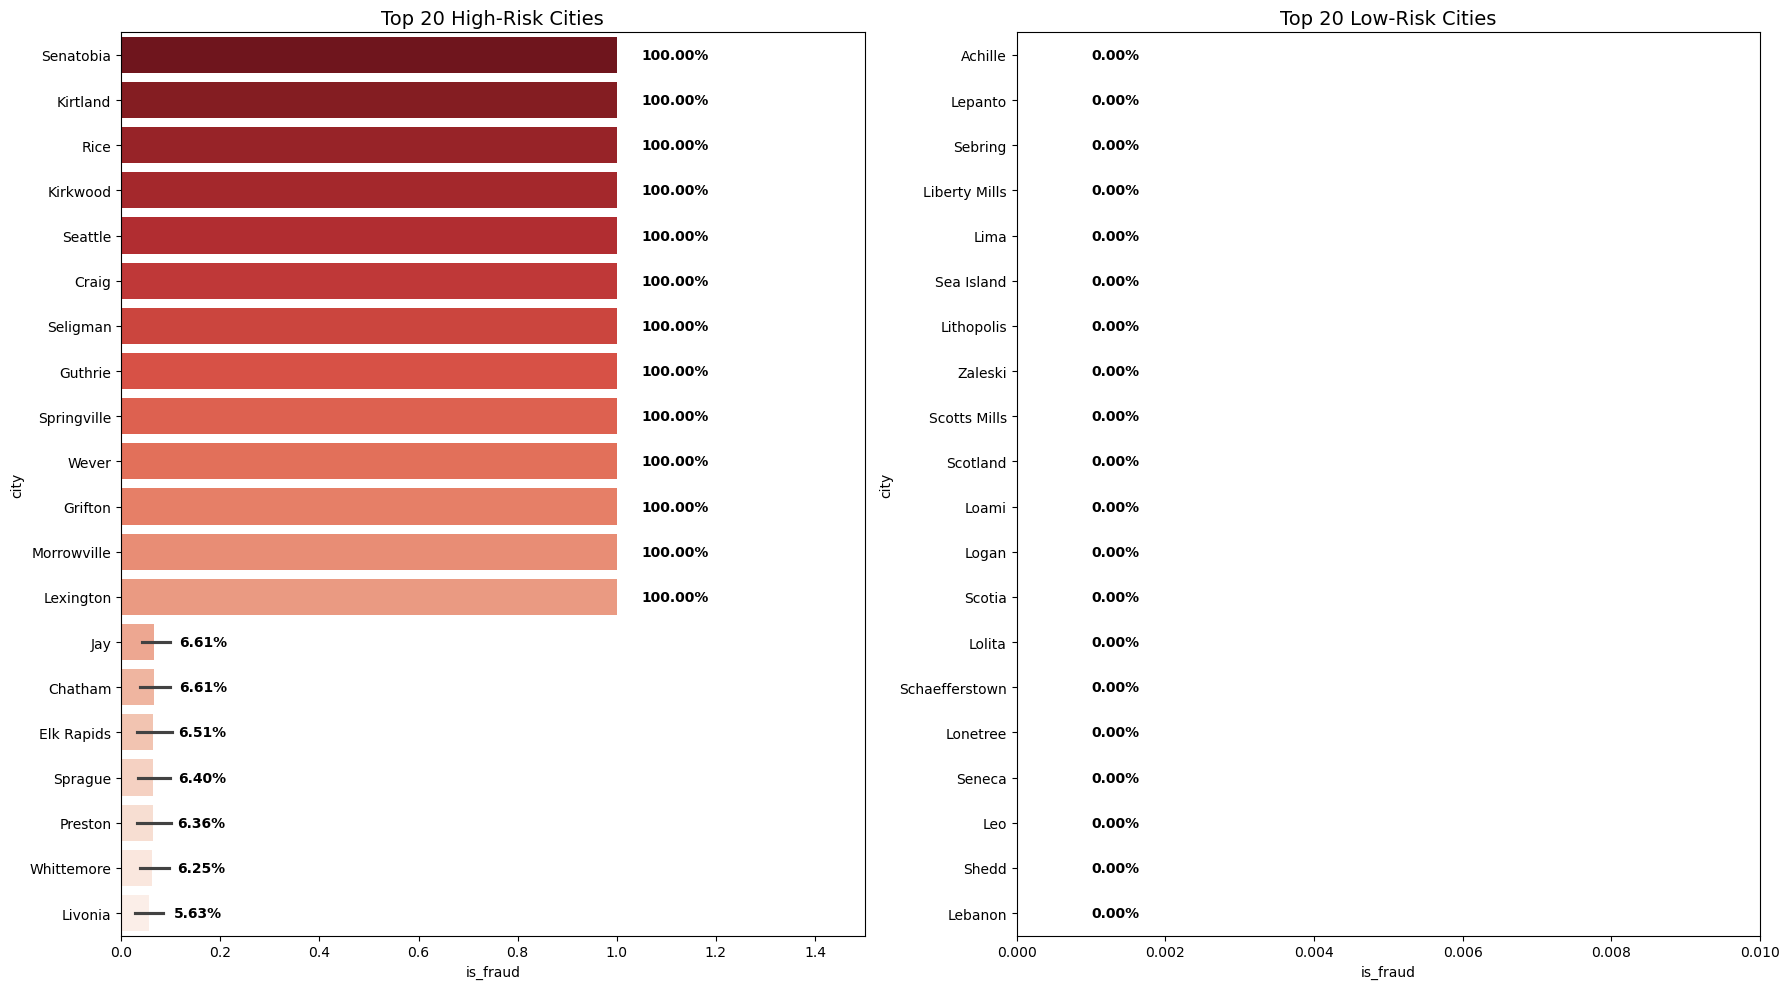

In [46]:
# 1. Setup figure with enough height for 20 items per side
fig, axes = plt.subplots(1, 2, figsize=(18, 10)) 

# --- PLOT 1: TOP 20 highest ---
# Get the order/names first
top_names = df_clean.groupby('city')['is_fraud'].mean().sort_values(ascending=False).head(20).index
# Filter raw data for these cities so we can get Error Bars
top_data = df_clean[df_clean['city'].isin(top_names)]

sns.barplot(data=top_data, x='is_fraud', y='city', ax=axes[0], 
            order=top_names, palette='Reds_r', errorbar='ci')

# Calculate labels and limits
max_val_top = top_data.groupby('city')['is_fraud'].mean().max()
for i, name in enumerate(top_names):
    v = df_clean[df_clean['city'] == name]['is_fraud'].mean()
    # Use a smaller offset but larger xlim padding
    axes[0].text(v + (max_val_top * 0.05), i, f'{v:.2%}', va='center', ha='left', fontweight='bold')

axes[0].set_title('Top 20 High-Risk Cities', fontsize=14)
axes[0].set_xlim(0, max_val_top * 1.5) # 50% extra space for labels

# --- PLOT 2: TOP 20 lowest ---
bottom_names = df_clean.groupby('city')['is_fraud'].mean().sort_values(ascending=True).head(20).index
bottom_data = df_clean[df_clean['city'].isin(bottom_names)]

sns.barplot(data=bottom_data, x='is_fraud', y='city', ax=axes[1], 
            order=bottom_names, palette='Blues_r', errorbar='ci')

max_val_bottom = bottom_data.groupby('city')['is_fraud'].mean().max()
for i, name in enumerate(bottom_names):
    v = df_clean[df_clean['city'] == name]['is_fraud'].mean()
    # Add a fallback for zero values so labels don't overlap the Y-axis
    x_pos = v + (max_val_bottom * 0.05) if max_val_bottom > 0 else 0.001
    axes[1].text(x_pos, i, f'{v:.2%}', va='center', ha='left', fontweight='bold')

axes[1].set_title('Top 20 Low-Risk Cities', fontsize=14)
# Ensure xlim isn't 0 if all fraud rates are 0
axes[1].set_xlim(0, max(max_val_bottom * 1.5, 0.01)) 

plt.tight_layout()
plt.show()

**Observation:** Certain city and street values show a 100% fraud_rate. This is likely due to insufficient observations (small sample size) rather than a genuine pattern. To prevent overfitting and skewed predictions, these high-cardinality features will be excluded from the model.

In [47]:
states_rate = calRate('state')
states_rate

,Category,Total,Fraud_Count,Fraud_Rate
0,AK,843,14,0.016607
6,CT,3277,40,0.012206
12,ID,2490,22,0.008835
10,HI,1090,9,0.008257
25,MT,5052,37,0.007324
7,DC,1517,10,0.006592
14,IN,11959,75,0.006271
36,OR,7811,48,0.006145
24,MS,8833,54,0.006113
44,VA,12506,75,0.005997


C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\4054827164.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_data, x='is_fraud', y='state', ax=axes[0],
C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\4054827164.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_data, x='is_fraud', y='state', ax=axes[1],


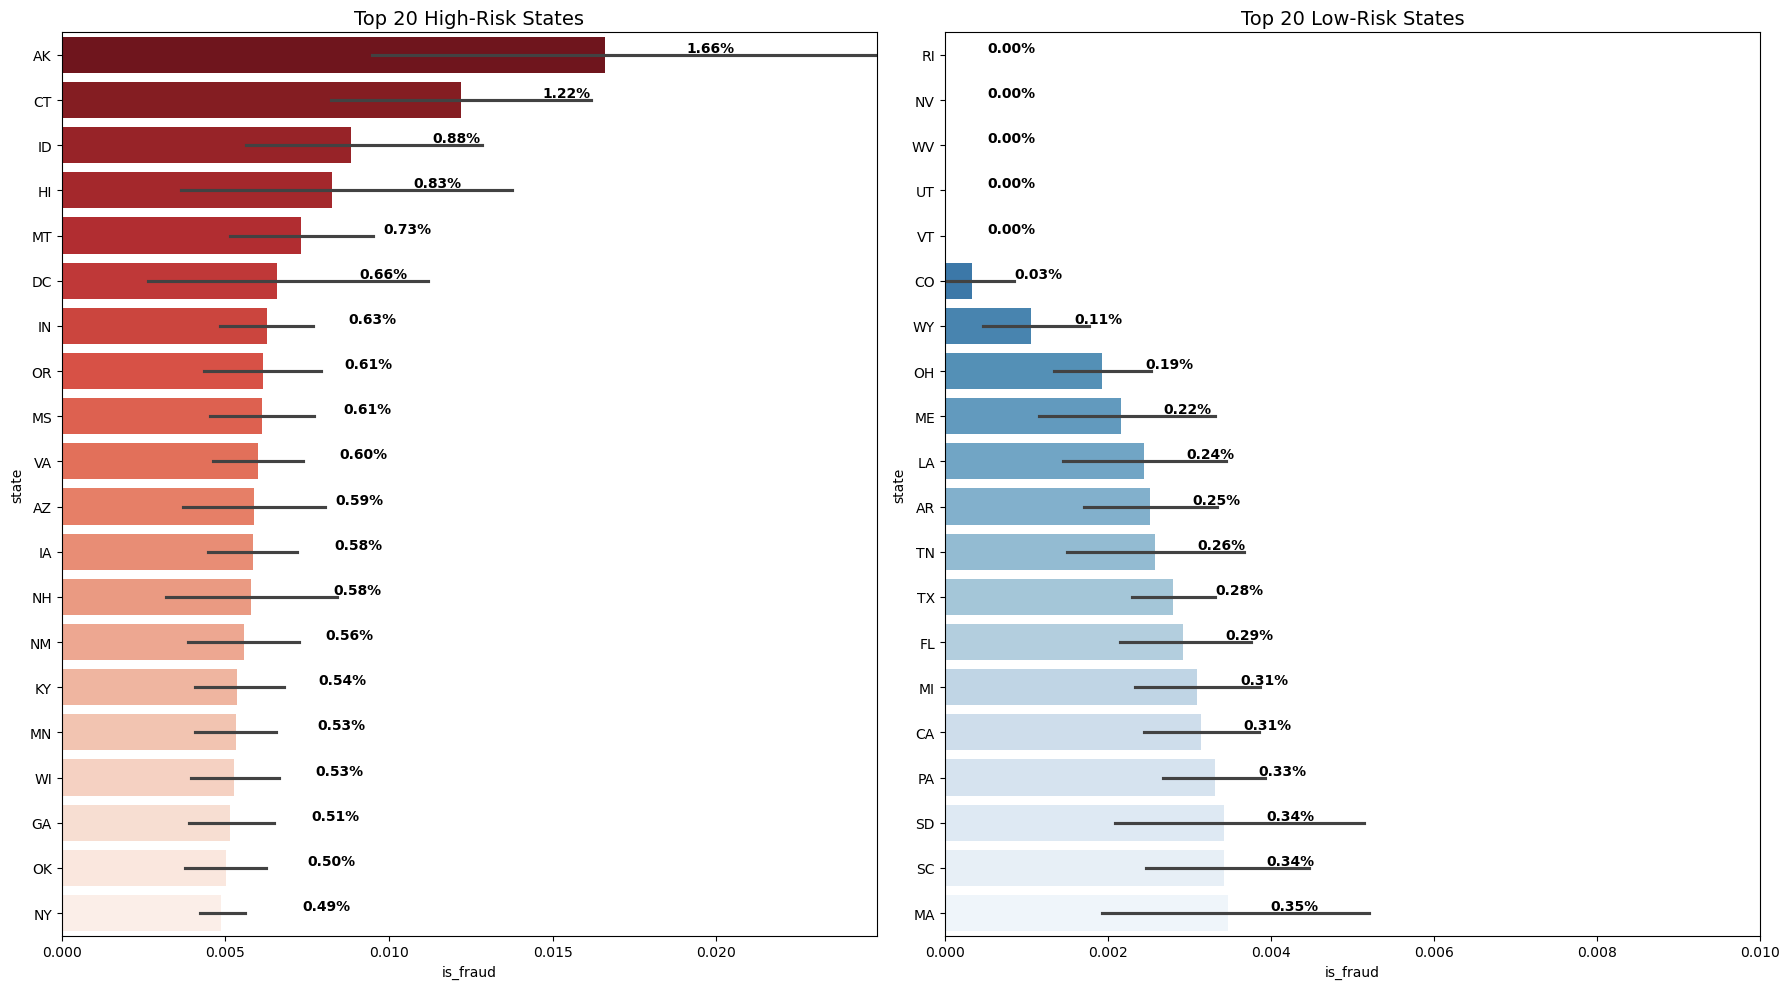

In [48]:
# 1. Setup figure with enough height for 20 items per side
fig, axes = plt.subplots(1, 2, figsize=(18, 10)) 

# --- PLOT 1: TOP 20 highest ---
# Get the order/names first
top_states = df_clean.groupby('state')['is_fraud'].mean().sort_values(ascending=False).head(20).index
# Filter raw data for these cities so we can get Error Bars
top_data = df_clean[df_clean['state'].isin(top_states)]

sns.barplot(data=top_data, x='is_fraud', y='state', ax=axes[0], 
            order=top_states, palette='Reds_r', errorbar='ci')

# Calculate labels and limits
max_val_top = top_data.groupby('state')['is_fraud'].mean().max()
for i, name in enumerate(top_states):
    v = df_clean[df_clean['state'] == name]['is_fraud'].mean()
    # Use a smaller offset but larger xlim padding
    axes[0].text(v + (max_val_top * 0.15), i, f'{v:.2%}', va='bottom', ha='left', fontweight='bold')

axes[0].set_title('Top 20 High-Risk States', fontsize=14)
axes[0].set_xlim(0, max_val_top * 1.5) 

# --- PLOT 2: TOP 20 lowest ---
bottom_states = df_clean.groupby('state')['is_fraud'].mean().sort_values(ascending=True).head(20).index
bottom_data = df_clean[df_clean['state'].isin(bottom_states)]

sns.barplot(data=bottom_data, x='is_fraud', y='state', ax=axes[1], 
            order=bottom_states, palette='Blues_r', errorbar='ci')

max_val_bottom = bottom_data.groupby('state')['is_fraud'].mean().max()
for i, name in enumerate(bottom_states):
    v = df_clean[df_clean['state'] == name]['is_fraud'].mean()
    # Add a fallback for zero values so labels don't overlap the Y-axis
    x_pos = v + (max_val_bottom * 0.15) if max_val_bottom > 0 else 0.001
    axes[1].text(x_pos, i, f'{v:.2%}', va='bottom', ha='left', fontweight='bold')

axes[1].set_title('Top 20 Low-Risk States', fontsize=14)
# Ensure xlim isn't 0 if all fraud rates are 0
axes[1].set_xlim(0, max(max_val_bottom * 1.5, 0.01)) 

plt.tight_layout()
plt.show()

In [49]:
jobs_rate = calRate('job')
jobs_rate

,Category,Total,Fraud_Count,Fraud_Rate
167,"Engineer, water",8,8,1.000000
307,Operational investment banker,11,11,1.000000
411,Software engineer,11,11,1.000000
219,Horticultural consultant,213,12,0.056338
1,"Accountant, chartered certified",217,12,0.055300
...,...,...,...,...
198,Futures trader,1724,0,0.000000
196,Furniture designer,891,0,0.000000
194,Freight forwarder,1399,0,0.000000
192,Fitness centre manager,1113,0,0.000000


C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\4131127123.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_data, x='is_fraud', y='job', ax=axes[0],
C:\Users\DELL\AppData\Local\Temp\ipykernel_21232\4131127123.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_data, x='is_fraud', y='job', ax=axes[1],


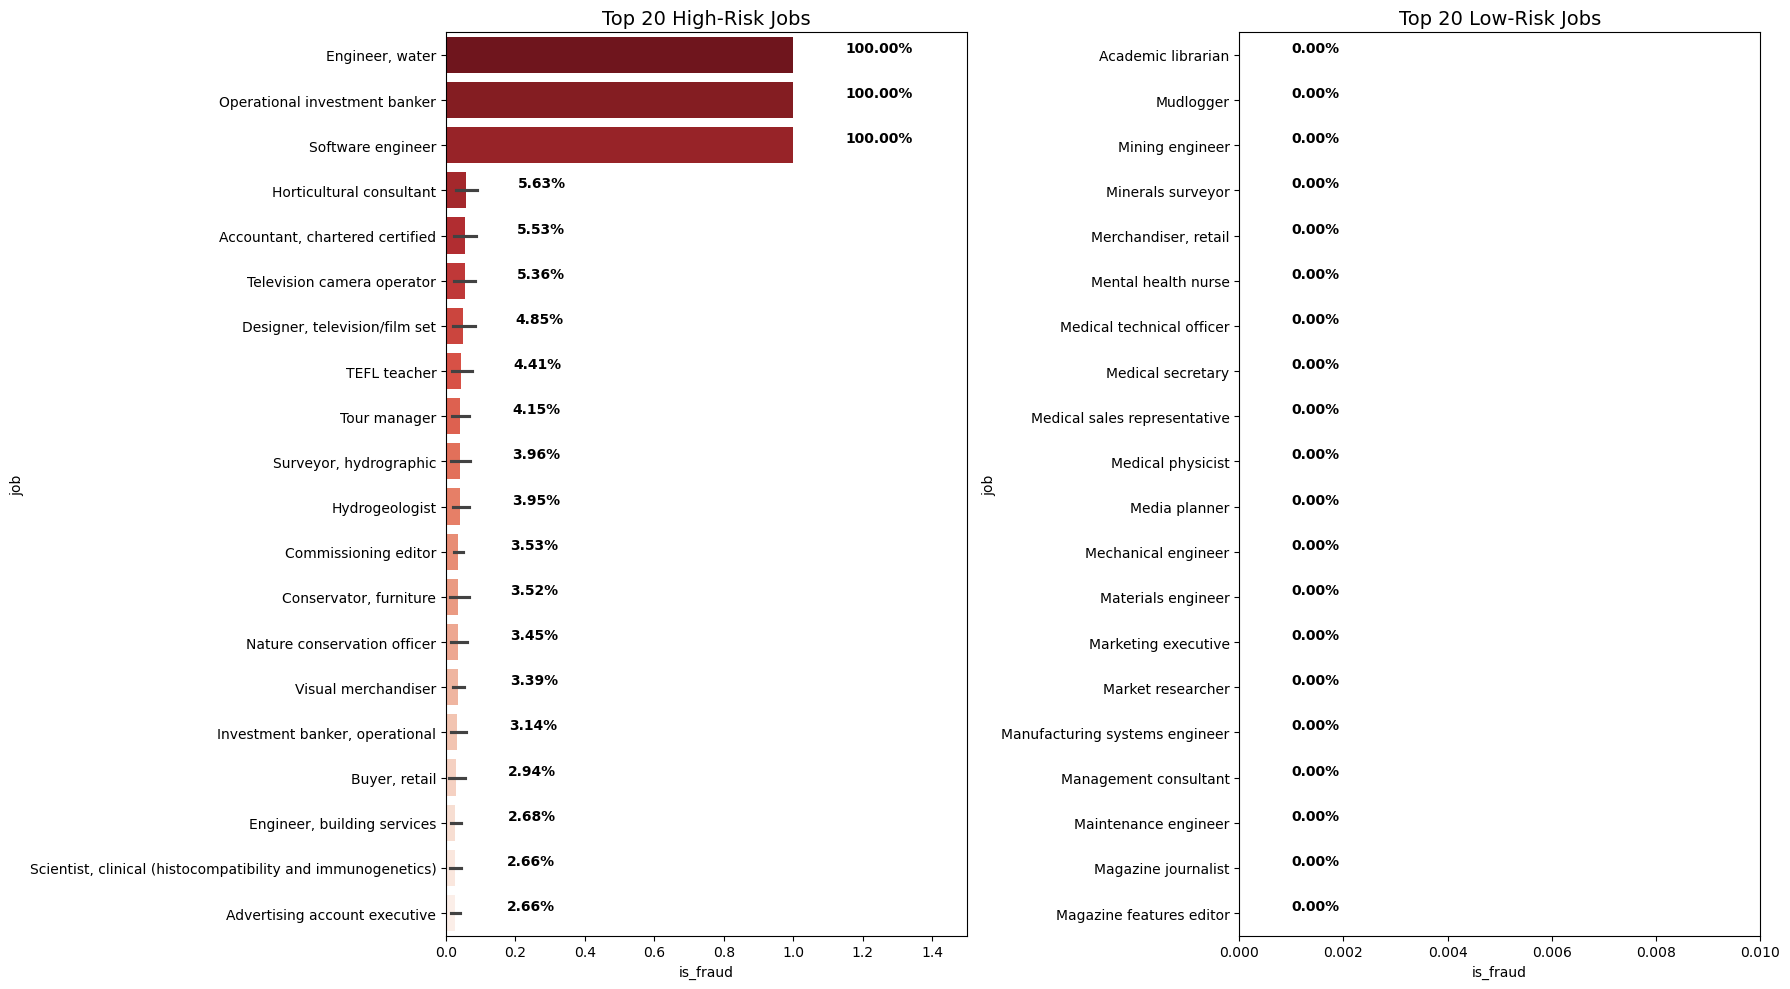

In [50]:
# 1. Setup figure with enough height for 20 items per side
fig, axes = plt.subplots(1, 2, figsize=(18, 10)) 

# --- PLOT 1: TOP 20 highest ---
# Get the order/names first
top_jobs = df_clean.groupby('job')['is_fraud'].mean().sort_values(ascending=False).head(20).index
# Filter raw data for these cities so we can get Error Bars
top_data = df_clean[df_clean['job'].isin(top_jobs)]

sns.barplot(data=top_data, x='is_fraud', y='job', ax=axes[0], 
            order=top_jobs, palette='Reds_r', errorbar='ci')

# Calculate labels and limits
max_val_top = top_data.groupby('job')['is_fraud'].mean().max()
for i, name in enumerate(top_jobs):
    v = df_clean[df_clean['job'] == name]['is_fraud'].mean()
    # Use a smaller offset but larger xlim padding
    axes[0].text(v + (max_val_top * 0.15), i, f'{v:.2%}', va='bottom', ha='left', fontweight='bold')

axes[0].set_title('Top 20 High-Risk Jobs', fontsize=14)
axes[0].set_xlim(0, max_val_top * 1.5) 

# --- PLOT 2: TOP 20 lowest ---
bottom_jobs = df_clean.groupby('job')['is_fraud'].mean().sort_values(ascending=True).head(20).index
bottom_data = df_clean[df_clean['job'].isin(bottom_jobs)]

sns.barplot(data=bottom_data, x='is_fraud', y='job', ax=axes[1], 
            order=bottom_jobs, palette='Blues_r', errorbar='ci')

max_val_bottom = bottom_data.groupby('job')['is_fraud'].mean().max()
for i, name in enumerate(bottom_jobs):
    v = df_clean[df_clean['job'] == name]['is_fraud'].mean()
    # Add a fallback for zero values so labels don't overlap the Y-axis
    x_pos = v + (max_val_bottom * 0.15) if max_val_bottom > 0 else 0.001
    axes[1].text(x_pos, i, f'{v:.2%}', va='bottom', ha='left', fontweight='bold')

axes[1].set_title('Top 20 Low-Risk Jobs', fontsize=14)
# Ensure xlim isn't 0 if all fraud rates are 0
axes[1].set_xlim(0, max(max_val_bottom * 1.5, 0.01)) 

plt.tight_layout()
plt.show()

**Observation:** Same situation as cities and streets

In [51]:
df_clean['unix_time'].is_unique

False

In [52]:
df_clean.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'street', 'city',
       'state', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'day', 'month', 'year', 'hour', 'minute',
       'day_of_week', 'is_weekend', 'age', 'distance_km', 'is_first_txn',
       'is_invalid_latlong', 'dist_from_prev_txn', 'time_diff_sec', 'speed',
       'amt_vs_historical_ratio', 'trans_count_24h', 'total_amt_24h',
       'avg_amt_7d', 'avg_amt_30d', 'amt_perc_of_24h', 'ratio_vs_7d',
       'ratio_vs_30d'],
      dtype='object')

To capture both long-term patterns and short-term anomalies for each merchant, two frequency-based features are engineered:
- merch_exp_count (Long-term Exposure): The cumulative number of times this merchant appears in the entire historical dataset. This represents the merchant's overall "trust" or "presence" in the system.
- merch_velocity_24h (Short-term Velocity): The total number of transactions processed by this merchant within a rolling 24-hour window.

In [20]:
# merchant category is a very high-cardinality columns 
# therefore I extract 2 value from this columns which i think is the most valuable information
# expanding count: Accumulated show up times of this merchant in the whole historical transaction
# Rolling Count 24h: Accumulated show up times of this merchant within 24h

# using a temporary index to ensure that the rolling value will return into the correct data point
df_clean['temp_id'] = range(len(df_clean))
df_clean = df_clean.sort_values(['unix_time', 'temp_id'])
df_clean['timestamp'] = pd.to_datetime(df_clean['unix_time'], unit='s')
df_clean = df_clean.set_index('timestamp')

# 1. Expanding Count
df_clean['merch_exp_count'] = df_clean.groupby('merchant').cumcount()

# 2. Rolling Count 24h
df_clean['merch_velocity_24h'] = (
    df_clean.groupby('merchant', group_keys=False)['amt']
    .rolling(window='24h', closed='left')
    .count()
    .values
)

df_clean = df_clean.sort_values('temp_id')

# Fill NaN = 0 for the first time 
df_clean[['merch_exp_count', 'merch_velocity_24h']] = df_clean[['merch_exp_count', 'merch_velocity_24h']].fillna(0)

# Drop redundant columns
df_clean.drop(columns=['merchant', 'temp_id'], inplace=True)

In [21]:
numeric_cols_2 = df_clean.select_dtypes(include=['number']).columns
numeric_cols_2

Index(['cc_num', 'amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'day', 'month', 'year', 'hour', 'minute',
       'day_of_week', 'is_weekend', 'age', 'distance_km', 'is_first_txn',
       'is_invalid_latlong', 'dist_from_prev_txn', 'time_diff_sec', 'speed',
       'amt_vs_historical_ratio', 'trans_count_24h', 'total_amt_24h',
       'avg_amt_7d', 'avg_amt_30d', 'amt_perc_of_24h', 'ratio_vs_7d',
       'ratio_vs_30d', 'merch_exp_count', 'merch_velocity_24h'],
      dtype='object')

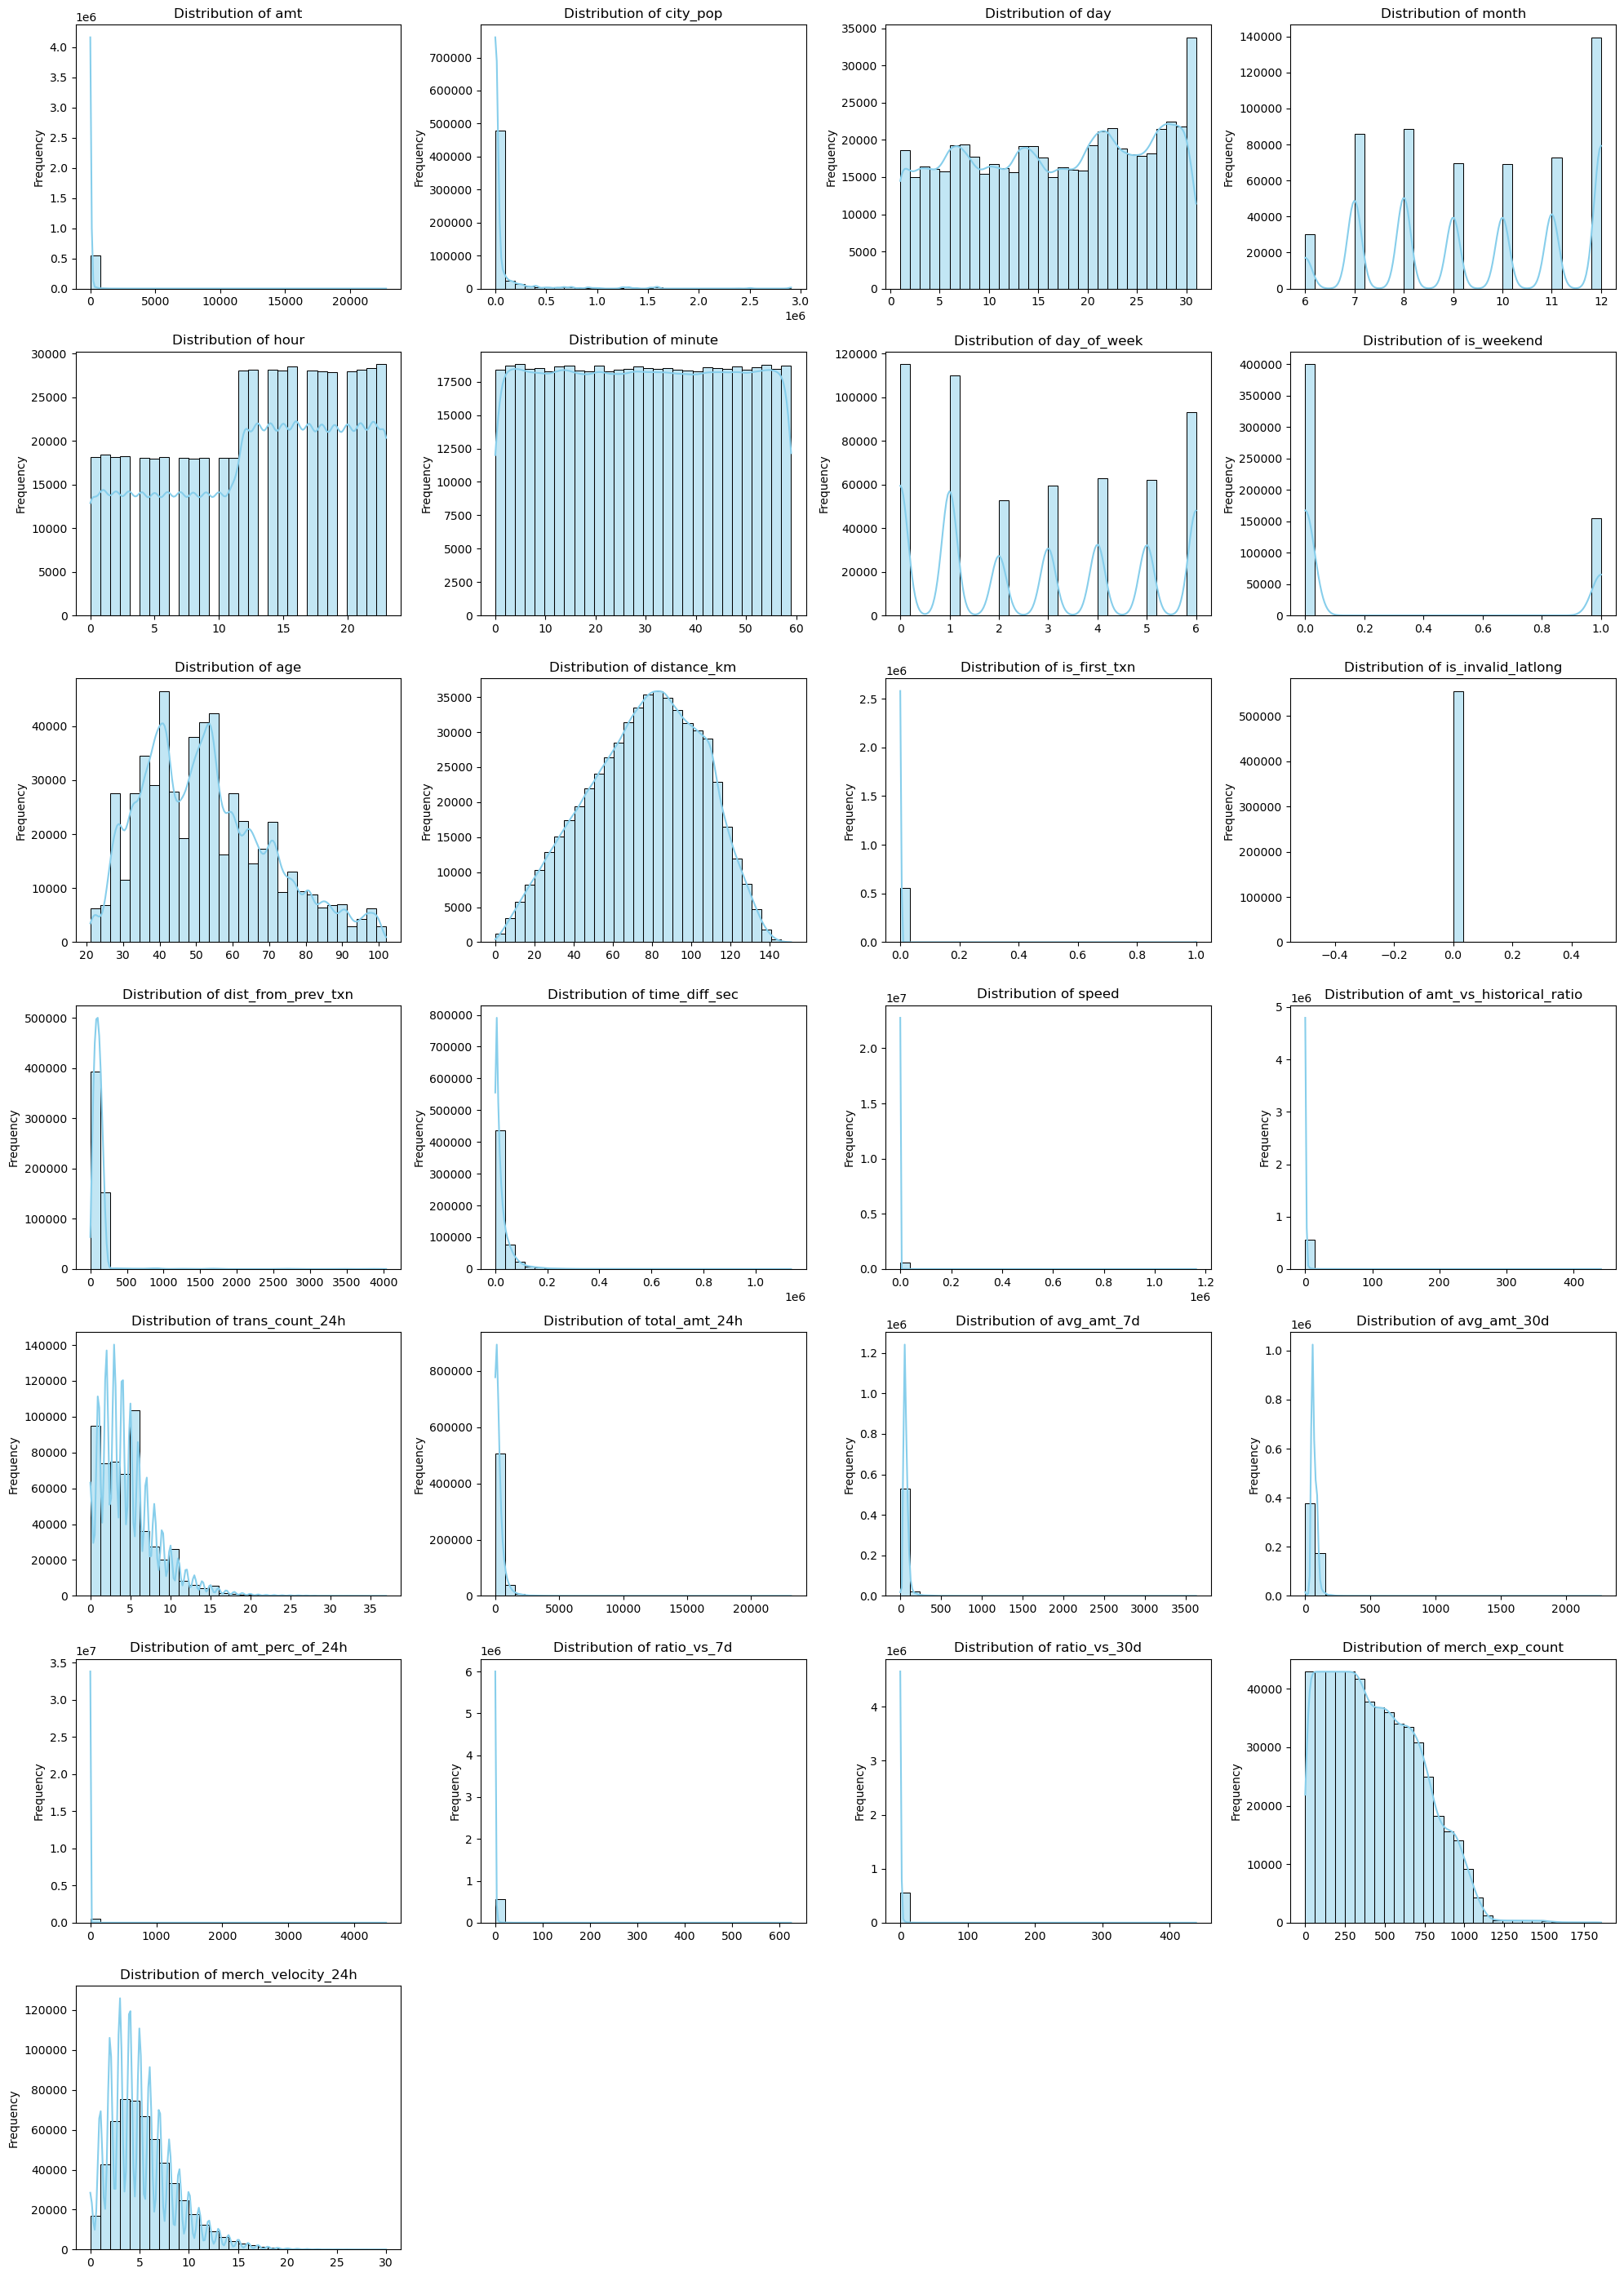

In [55]:
exclude_cols = ['cc_num', 'lat', 'long', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud','year']
,
# 2. Filter the numeric columns list
# This ensures we only loop through what we actually want to plot
plot_cols = [col for col in numeric_cols_2 if col not in exclude_cols]

# 3. Calculate grid size based on the FILTERED list
n_cols = 4
n_rows = math.ceil(len(plot_cols) / n_cols)

# 4. Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

# 5. Loop through the filtered 'plot_cols'
for i, col in enumerate(plot_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# 6. Remove any extra empty subplots
for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('hist_plot.png', dpi=300, bbox_inches='tight') 
plt.show()

**Observation**: Histograms of engineered numeric features reveal high skewness and long-tail distributions across vast ranges.
- The Challenge: Such distributions risk model overfitting to extreme outliers while potentially neglecting patterns in the majority of the data.
- The Paradox: In fraud detection, outliers are often the "signal" rather than "noise"—they are statistically priceless.
- Strategy: To balance this, robust transformation (e.g., Log or Yeo-Johnson) and scaling (e.g., RobustScaler) will be applied. This reduces the negative impact of extreme scales while preserving the critical patterns necessary for fraud identification.

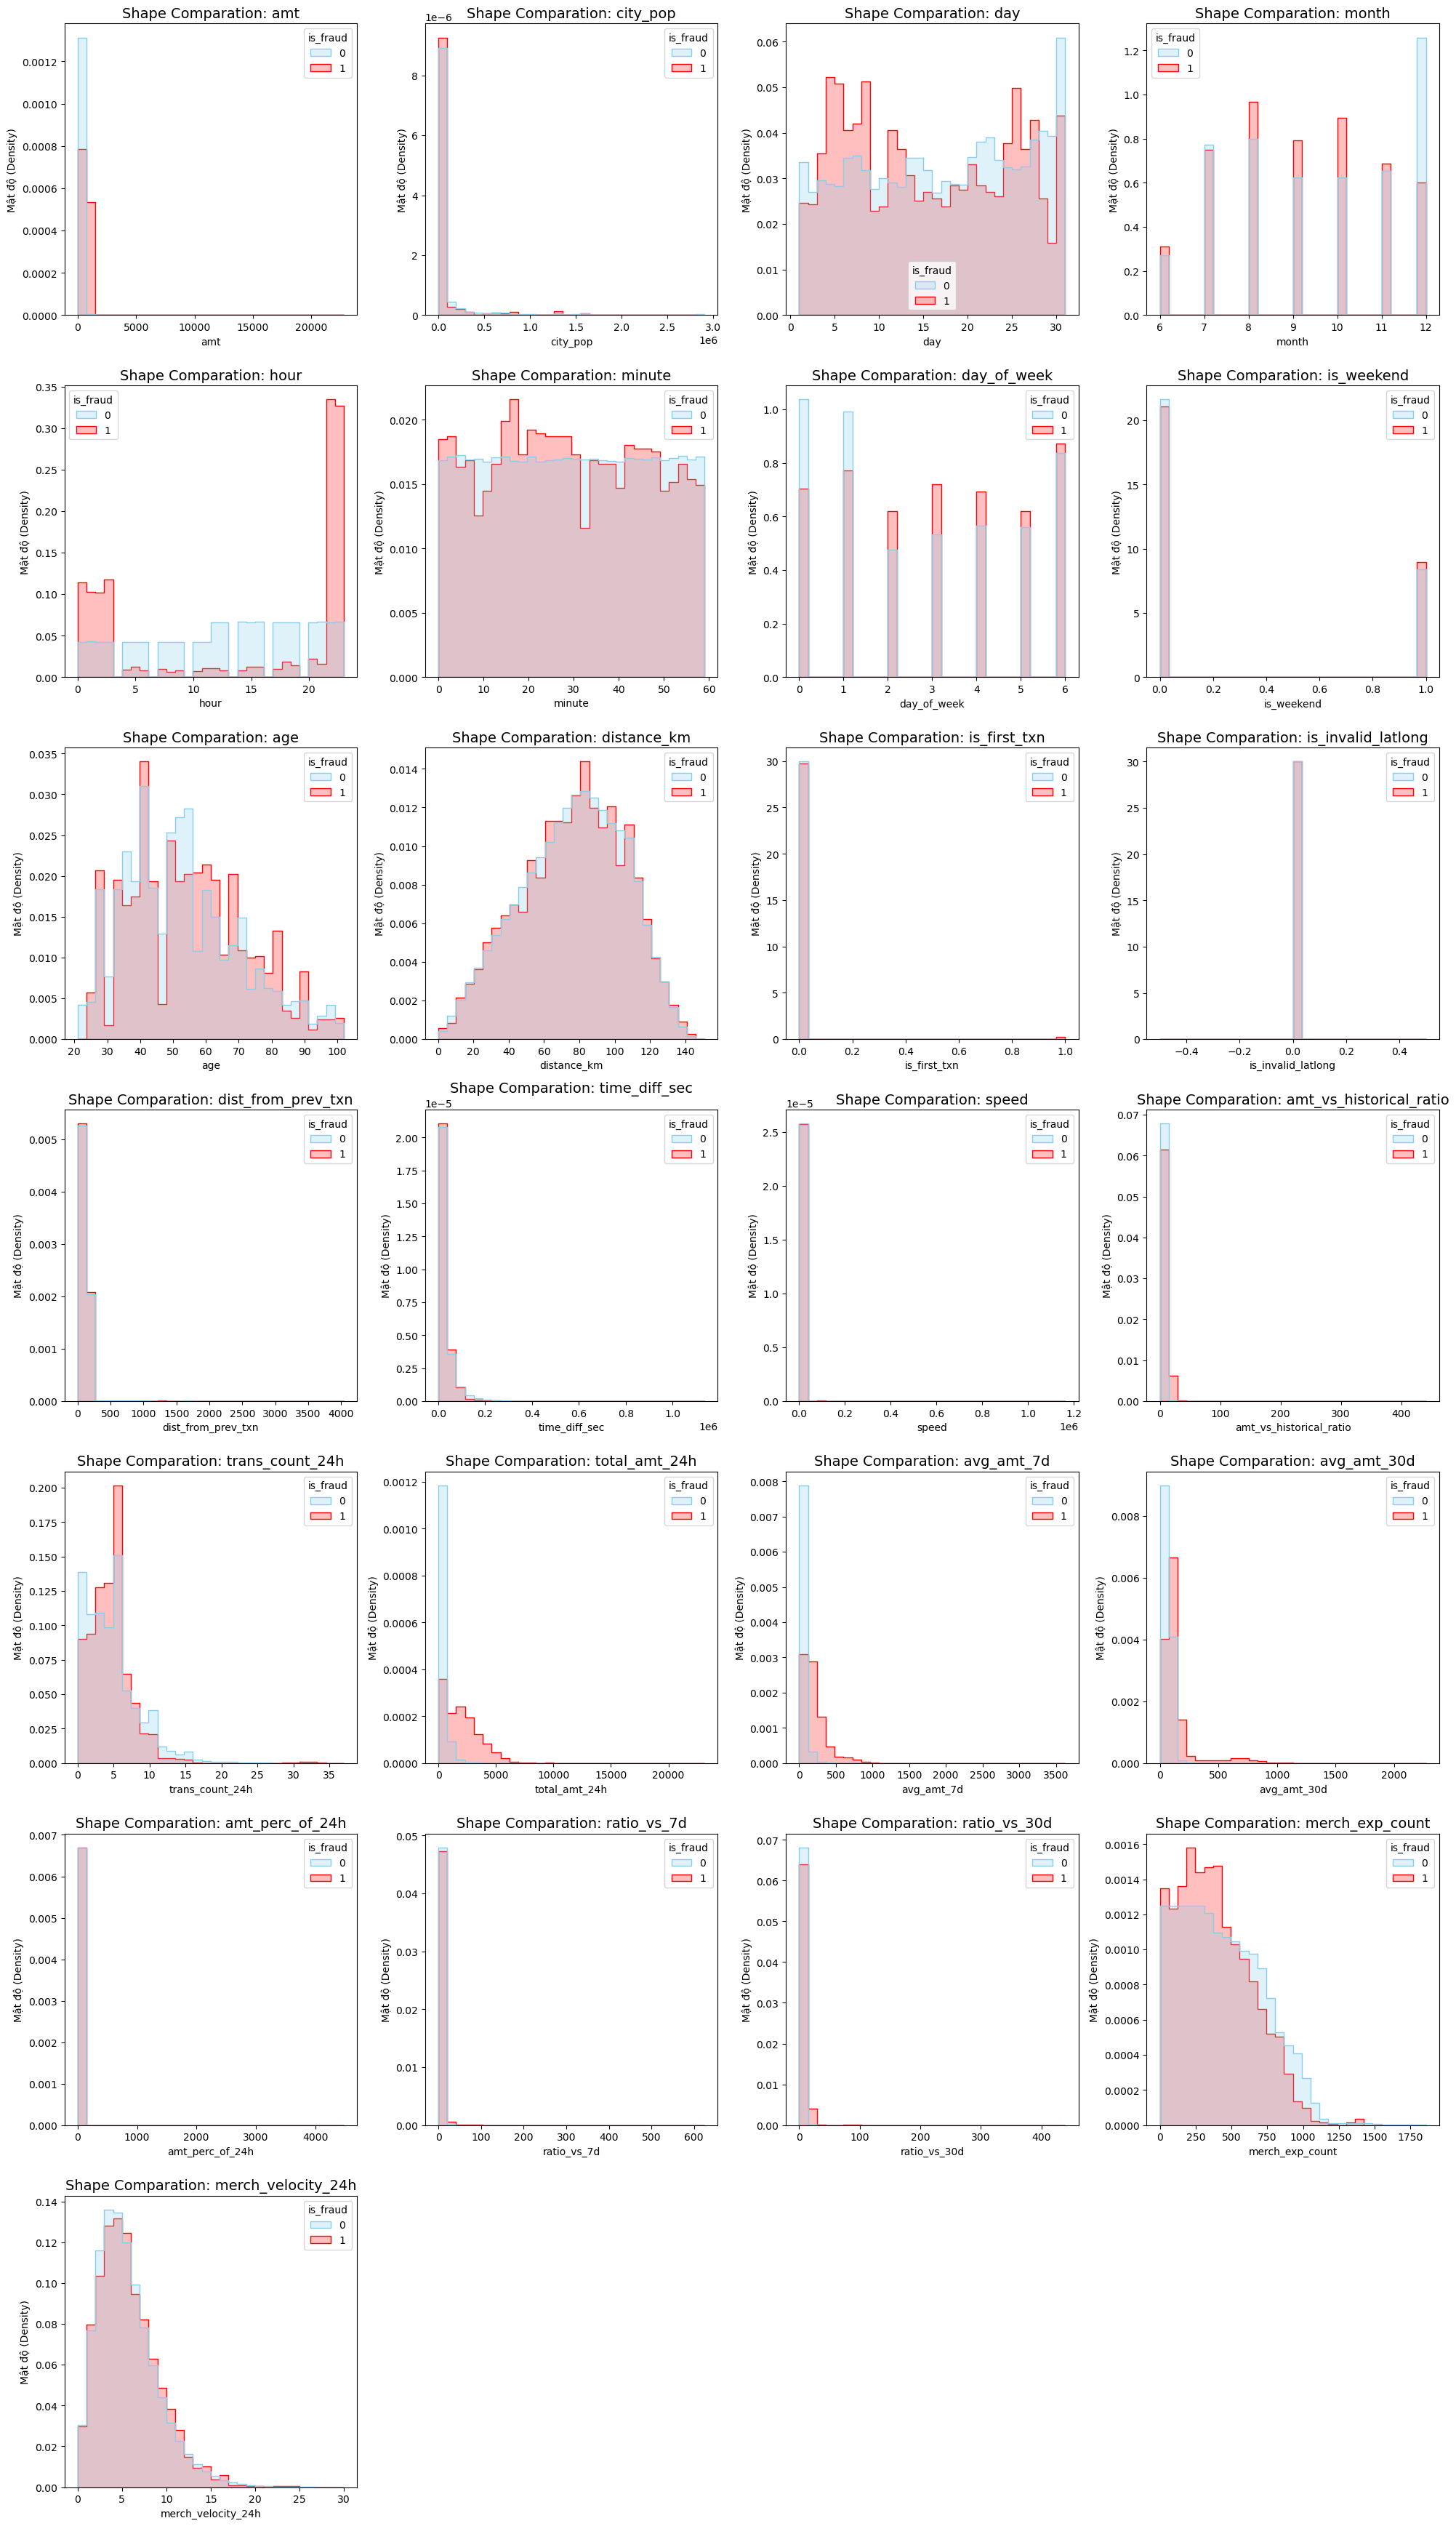

In [56]:
# this plot drawing histogram but using different colors to illustrate safe/fraudulent transaction
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.histplot(
        data=df_clean, 
        x=col, 
        hue='is_fraud', 
        kde=False,            
        element="step",      
        stat="density",      
        common_norm=False,    
        palette={0: 'skyblue', 1: 'red'}, 
        ax=axes[i], 
        bins=30
    )
    axes[i].set_title(f'Shape Comparation: {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Mật độ (Density)')

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
df_clean.columns

Index(['cc_num', 'category', 'amt', 'gender', 'street', 'city', 'state', 'lat',
       'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'day', 'month', 'year', 'hour', 'minute', 'day_of_week',
       'is_weekend', 'age', 'distance_km', 'is_first_txn',
       'is_invalid_latlong', 'dist_from_prev_txn', 'time_diff_sec', 'speed',
       'amt_vs_historical_ratio', 'trans_count_24h', 'total_amt_24h',
       'avg_amt_7d', 'avg_amt_30d', 'amt_perc_of_24h', 'ratio_vs_7d',
       'ratio_vs_30d', 'merch_exp_count', 'merch_velocity_24h'],
      dtype='object')

# TEST AND TRAIN SET SPLIT  
In fraud detection, maintaining the temporal order of transactions is critical. Spending patterns evolve over time, and a model must be evaluated on its ability to predict future fraud based on past data.
- Sorting: The dataset is first ordered chronologically using the unix_time column.
- Split Strategy: A Time-Series Split is executed instead of a random shuffle.
- Data Integrity: shuffle=False is strictly applied during the split. This ensures that the training set strictly precedes the test set in time, preventing temporal leakage (where the model accidentally "sees" future patterns during training).

In [19]:
df_clean = df_clean.sort_values('unix_time')

In [20]:
X = df_clean.drop('is_fraud', axis=1)
y = df_clean['is_fraud']

In [21]:
# Use stratify split to ensure the target variable distribution pattern
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, shuffle=False, random_state = 42)
X_train.shape

(444575, 37)

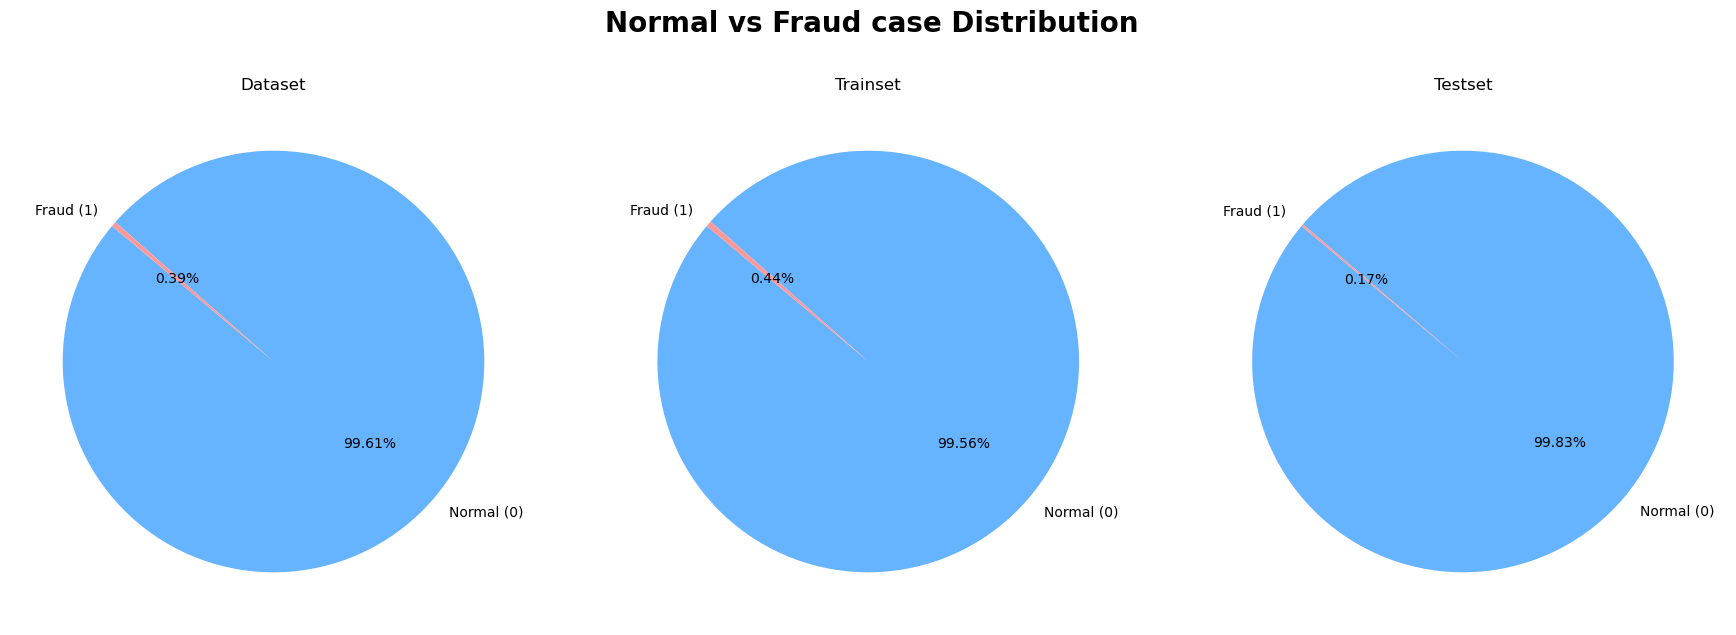

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fraud_counts = credit_df['is_fraud'].value_counts()
fraud_counts_train = y_train.value_counts()
fraud_counts_test = y_test.value_counts()

labels = ['Normal (0)', 'Fraud (1)']
colors = ['#66b3ff', '#ff9999'] 

axes[0].pie(fraud_counts, 
        labels=labels, 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=colors)
axes[0].set_title('Dataset')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(fraud_counts_train, 
        labels=labels, 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=colors)

axes[1].set_title('Trainset')
axes[1].tick_params(axis='x', rotation=45)

axes[2].pie(fraud_counts_test, 
        labels=labels, 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=colors)

axes[2].set_title('Testset')
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle('Normal vs Fraud case Distribution', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Observation:** The pie chart illustrates an imbalance in the distribution of fraud cases across different sets. The original dataset contains 0.39% fraud, while the training set holds 0.44%, and the test set accounts for only 0.17%.
- Methodological Insight: It is a direct consequence of using a Temporal Split instead of a Stratified Split. Unlike stratification, a temporal split does not guarantee consistent class proportions as it prioritizes the chronological integrity of the data.
- Although the fraud rate in the test set is lower, this distribution is acceptable. It reflects real-world scenarios where fraud occurrences are rare and highly non-stationary (fluctuating over time).
- Conclusion: The training set still contains a sufficient volume of fraudulent transactions for the model to effectively learn minority class patterns.

# DATA PREPARATION

In [25]:
numeric_cols_trainset = X_train.select_dtypes(include=['number']).columns
len(numeric_cols_trainset)

32

In [26]:
skewness = X_train[numeric_cols_trainset].apply(lambda x: skew(x.dropna()))
skewness = skewness.sort_values(ascending=False)

high_skew_cols = skewness[abs(skewness) > 0.75].index
print(high_skew_cols)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21348\3145938177.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = X_train[numeric_cols_trainset].apply(lambda x: skew(x.dropna()))


Index(['amt_perc_of_24h', 'speed', 'ratio_vs_7d', 'ratio_vs_30d',
       'amt_vs_historical_ratio', 'amt', 'is_first_txn', 'dist_from_prev_txn',
       'avg_amt_7d', 'avg_amt_30d', 'total_amt_24h', 'city_pop',
       'time_diff_sec', 'cc_num', 'trans_count_24h', 'merch_velocity_24h',
       'is_weekend', 'merch_long', 'long'],
      dtype='object')


In [27]:
transform_cols = [
    'amt','avg_amt_7d','total_amt_24h','avg_amt_30d',
    'city_pop','speed','time_diff_sec','dist_from_prev_txn',
    'amt_perc_of_24h', 'ratio_vs_7d', 'ratio_vs_30d', 'amt_vs_historical_ratio']
X_train_copy = X_train.copy() 
for col in transform_cols:
    X_train_copy[col] = np.log1p(X_train[col])

In [27]:
print(X_train_copy[transform_cols].isnull().sum())

amt                        0
avg_amt_7d                 0
total_amt_24h              0
avg_amt_30d                0
city_pop                   0
speed                      0
time_diff_sec              0
dist_from_prev_txn         0
amt_perc_of_24h            0
ratio_vs_7d                0
ratio_vs_30d               0
amt_vs_historical_ratio    0
dtype: int64


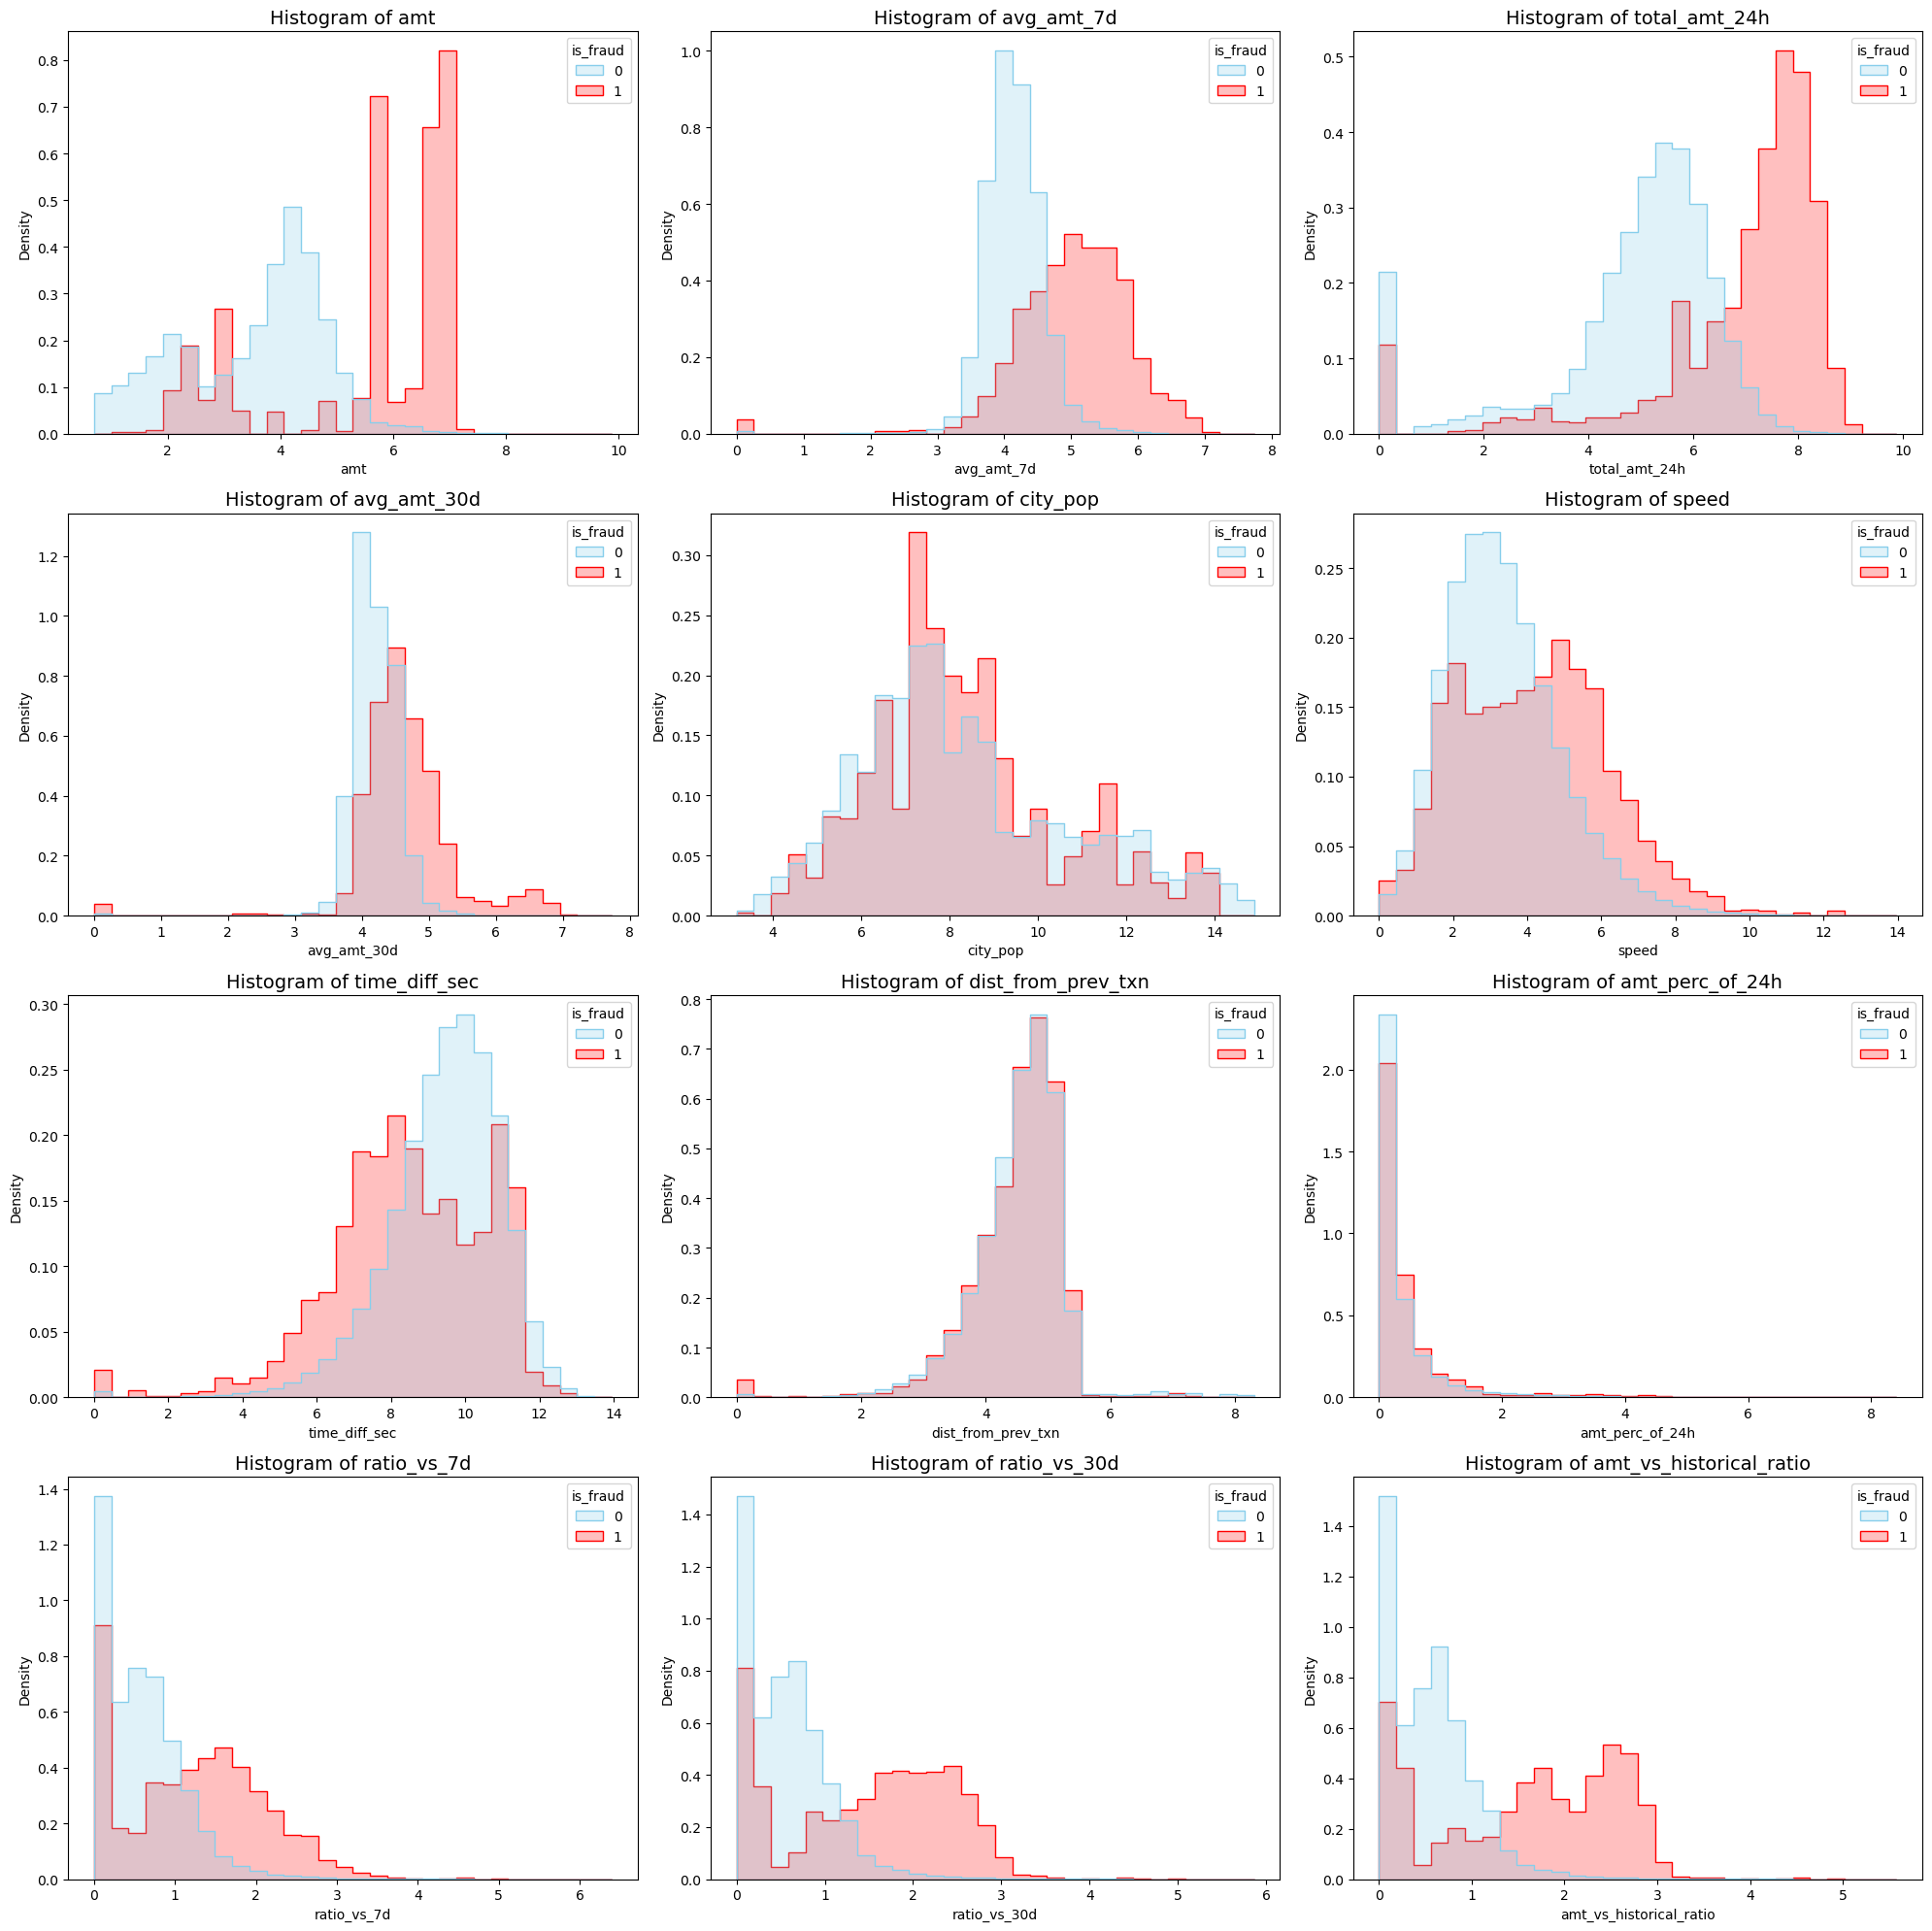

In [66]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(transform_cols):
    sns.histplot(
        data=X_train_copy.assign(is_fraud=y_train), 
        x=col, 
        hue='is_fraud', 
        kde=False,            
        element="step",       
        stat="density",       
        common_norm=False,    
        palette={0: 'skyblue', 1: 'red'}, 
        ax=axes[i], 
        bins=30
    )
    axes[i].set_title(f'Histogram of {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# 5. Xóa các ô trống
for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [28]:
X_train.columns

Index(['cc_num', 'category', 'amt', 'gender', 'street', 'city', 'state', 'lat',
       'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long',
       'day', 'month', 'year', 'hour', 'minute', 'day_of_week', 'is_weekend',
       'age', 'distance_km', 'is_first_txn', 'is_invalid_latlong',
       'dist_from_prev_txn', 'time_diff_sec', 'speed',
       'amt_vs_historical_ratio', 'trans_count_24h', 'total_amt_24h',
       'avg_amt_7d', 'avg_amt_30d', 'amt_perc_of_24h', 'ratio_vs_7d',
       'ratio_vs_30d', 'merch_exp_count', 'merch_velocity_24h'],
      dtype='object')

In [22]:
# cyclic encodings to create a pair of sin,cos index for each time feature
def sin_transformer(x, max_val):
    return np.sin(2 * np.pi * x / max_val)

def cos_transformer(x, max_val):
    return np.cos(2 * np.pi * x / max_val)

In [23]:
num_log_robust_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('robust', RobustScaler())
])

After the initial data discovery, features are categorized into specific groups to apply tailored transformation and scaling techniques. All processes are encapsulated within a comprehensive processor (Pipeline) to ensure reproducibility and prevent data leakage. The feature groups include:
- cyclic_cols: Applied Sin-Cos Encoding to temporal features to preserve their cyclic nature (e.g., ensuring hour 23 is mathematically close to hour 0).
- log_rob_cols: Features exhibiting high skewness and extreme outliers are treated with a Log Transformation followed by Robust Scaling. This mitigates the impact of long-tail distributions.
- robust_cols: Standardized using RobustScaler, focusing on features where outliers are present but do not require log transformation.
- standard_cols: Applied StandardScaler to features with narrower ranges, such as geographical coordinates and counting variables, to maintain their natural distribution.
- onehot_cols: Processed via One-Hot Encoding for the remaining low-cardinality categorical attributes.
- pass_through_cols: Includes boolean and binary features that do not require further transformation.

In [30]:
pass_through_cols = ['is_weekend', 'is_first_txn', 'is_invalid_latlong']
cyclic_cols = ['day', 'month', 'hour', 'minute', 'day_of_week']
robust_cols = ['distance_km']
log_rob_cols = [ 'amt','avg_amt_7d','total_amt_24h','avg_amt_30d',
                'city_pop','speed','time_diff_sec','dist_from_prev_txn',
                'amt_perc_of_24h', 'ratio_vs_7d', 'ratio_vs_30d', 'amt_vs_historical_ratio']
standard_cols = ['lat', 'long', 'merch_lat', 'merch_long', 'trans_count_24h','merch_exp_count', 'merch_velocity_24h']
onehot_cols = ['age_group','category','gender']

bins = [0, 35, 50, 75, 120]
labels = ['Young', 'Middle', 'Senior', 'Elderly']
X_train['age_group'] = pd.cut(X_train['age'], bins=bins, labels=labels)

X_train.drop(columns=[ 'cc_num', 'unix_time', 'year', 'street', 'city', 'state', 'job', 'age'])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_robust', RobustScaler(), robust_cols),
        ('num_log_rob', num_log_robust_pipe, log_rob_cols),
        ('num_std', StandardScaler(), standard_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ('hour_sin', FunctionTransformer(sin_transformer, kw_args={'max_val': 24}),['hour']),
        ('hour_cos', FunctionTransformer(cos_transformer, kw_args={'max_val': 24}),['hour']),
        ('day_sin', FunctionTransformer(sin_transformer, kw_args={'max_val': 31}),['day']),
        ('day_cos', FunctionTransformer(cos_transformer, kw_args={'max_val': 31}),['day']),
        ('month_sin', FunctionTransformer(sin_transformer, kw_args={'max_val': 12}),['month']),
        ('month_cos', FunctionTransformer(cos_transformer, kw_args={'max_val': 12}),['month']),
        ('minute_sin', FunctionTransformer(sin_transformer, kw_args={'max_val': 60}),['minute']),
        ('minute_cos', FunctionTransformer(cos_transformer, kw_args={'max_val': 60}),['minute']),
        ('day_of_week_sin', FunctionTransformer(sin_transformer, kw_args={'max_val': 7}),['day_of_week']),
        ('day_of_week_cos', FunctionTransformer(cos_transformer, kw_args={'max_val': 7}),['day_of_week']),
        ('pass', 'passthrough', ['is_weekend', 'is_first_txn', 'is_invalid_latlong'])    
    ],
    remainder='drop'
)
# scaling numeric feature and 
# encoding categorical feature

In [31]:
X_train_final = preprocessor.fit_transform(X_train, y_train)
X_train_final[1]

array([ 6.19052427e-01, -2.17948467e-01, -7.81972034e+00, -3.38710806e+00,
       -9.43867188e+00, -6.32408717e-01, -1.59365026e+00, -5.11532298e+00,
       -5.96618334e+00, -4.15068828e-01, -7.52480734e-01, -7.73570929e-01,
        2.65484891e-01,  3.51682708e-01, -1.47388834e+00,  1.78572541e-01,
       -1.43790462e+00, -1.32094963e+00, -1.53526202e+00, -1.23330641e+00,
        0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        1.22464680e-16, -1.00000000e+00, -8.97804540e-01, -4.40394152e-01,
        1.22464680e-16, -1.00000000e+00,  9.94521895e-01,  1.04528463e-01,
       -7.81831482e-01,  6.23489802e-01,  1.00000000e+00,  1.00000000e+00,
        0.00000000e+00])

In [33]:
X_test.columns

Index(['cc_num', 'category', 'amt', 'gender', 'street', 'city', 'state', 'lat',
       'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long',
       'day', 'month', 'year', 'hour', 'minute', 'day_of_week', 'is_weekend',
       'age', 'distance_km', 'is_first_txn', 'is_invalid_latlong',
       'dist_from_prev_txn', 'time_diff_sec', 'speed',
       'amt_vs_historical_ratio', 'trans_count_24h', 'total_amt_24h',
       'avg_amt_7d', 'avg_amt_30d', 'amt_perc_of_24h', 'ratio_vs_7d',
       'ratio_vs_30d', 'merch_exp_count', 'merch_velocity_24h'],
      dtype='object')

**Observation:** After completing the transformation and scaling phase, the dataset contains 38 independent variables. Post one-hot encoding, the dimensionality will increase significantly, potentially leading to a high-complexity model and increased computational overhead.To optimize model performance and maintain interpretability, a Feature Selection step is executed using a Random Forest approach. By leveraging the model's built-in Feature Importance (Gini Importance), we can identify and retain only the most influential predictors while discarding redundant or low-impact features.

In [73]:
# random forest model to calculate the feature importance
rf_model = RandomForestClassifier(
    n_jobs=-1,        
    random_state=42   
)

rf_model.fit(X_train_final,y_train)

cat_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out())
custom_feature_names = (
    robust_cols + 
    log_rob_cols +
    standard_cols + 
    # 4. cat (category, gender)
    cat_feature_names + 
    # 5. Sin/Cos
    ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 
     'month_sin', 'month_cos', 'minute_sin', 'minute_cos', 
     'day_of_week_sin', 'day_of_week_cos'] + 
    # 6. pass 
    ['is_weekend', 'is_first_txn', 'is_invalid_latlong']                                # pass
)
importances = rf_model.feature_importances_

In [74]:
fi_df = pd.DataFrame({
    'feature': custom_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
fi_df

,feature,importance
1,amt,0.157407
3,total_amt_24h,0.131186
2,avg_amt_7d,0.076709
12,amt_vs_historical_ratio,0.066394
9,amt_perc_of_24h,0.059426
10,ratio_vs_7d,0.054879
11,ratio_vs_30d,0.049462
4,avg_amt_30d,0.046276
41,hour_cos,0.038267
28,category_grocery_pos,0.033043


In [75]:
fi_df["importance"].sum()

np.float64(1.0)

**Observation:** During the feature transformation and scaling phase, several original variables were expanded into multiple derived components (category feature was divided to several dummies columns after using one-hot). Consequently, the raw importance scores are fragmented, reflecting only the impact of individual sub-features rather than the complete variable.
-> To restore a clear hierarchy of predictive power, I implemented a Feature Importance Aggregation process. This involves summing the importance scores of all related sub-components back into their parent features.

In [76]:
def aggregate_importance(df):
    mapping = {
        'hour': ['hour_sin', 'hour_cos'],
        'day': ['day_sin', 'day_cos'],
        'month': ['month_sin', 'month_cos'],
        'minute': ['minute_sin', 'minute_cos'],
        'day_of_week': ['day_of_week_sin','day_of_week_cos'],
        'location': ['lat', 'long', 'merch_lat', 'merch_long'],
        'category': [col for col in df['feature'] if 'category_' in col],
        'age_group': [col for col in df['feature'] if 'age_group' in col],
        'gender': [col for col in df['feature'] if 'gender' in col]
    }
    
    agg_data = []
    processed_features = []

    for root_name, sub_features in mapping.items():
        total_imp = df[df['feature'].isin(sub_features)]['importance'].sum()
        agg_data.append({'feature': root_name, 'importance': total_imp})
        processed_features.extend(sub_features)
    
    remaining_features = df[~df['feature'].isin(processed_features)]
    for _, row in remaining_features.iterrows():
        agg_data.append({'feature': row['feature'], 'importance': row['importance']})
        
    return pd.DataFrame(agg_data).sort_values(by='importance', ascending=False)

fi_agg_df = aggregate_importance(fi_df)
print(fi_agg_df)

                    feature  importance
9                       amt    0.157407
10            total_amt_24h    0.131186
11               avg_amt_7d    0.076709
12  amt_vs_historical_ratio    0.066394
6                  category    0.062486
13          amt_perc_of_24h    0.059426
14              ratio_vs_7d    0.054879
0                      hour    0.051014
15             ratio_vs_30d    0.049462
16              avg_amt_30d    0.046276
5                  location    0.044965
17            time_diff_sec    0.024180
18                    speed    0.020012
1                       day    0.018926
3                    minute    0.016946
19          trans_count_24h    0.016697
20          merch_exp_count    0.016413
21                 city_pop    0.014634
2                     month    0.014535
4               day_of_week    0.012597
22       dist_from_prev_txn    0.011911
23              distance_km    0.011660
7                 age_group    0.007761
24       merch_velocity_24h    0.007367


In [77]:
# watse alot of time 
# tomek = TomekLinks()
# X_resample, y_resample = tomek.fit_resample(X_train_final, y_train)

In [78]:
# try to use Random Forest with class_weight='balanced' to add the weight to imbalanced class 
#
rf_model_weight = RandomForestClassifier(
    n_jobs=-1,        
    random_state=42 ,
    class_weight='balanced'
)

rf_model_weight.fit(X_train_final,y_train)

importances_2 = rf_model_weight.feature_importances_
fi_df_2 = pd.DataFrame({
    'feature': custom_feature_names,
    'importance': importances_2
}).sort_values(by='importance', ascending=False)
fi_df_2

,feature,importance
1,amt,0.197408
3,total_amt_24h,0.146303
2,avg_amt_7d,0.113181
12,amt_vs_historical_ratio,0.106364
11,ratio_vs_30d,0.083398
41,hour_cos,0.072114
10,ratio_vs_7d,0.045480
4,avg_amt_30d,0.042987
9,amt_perc_of_24h,0.022652
40,hour_sin,0.016647


In [79]:
fi_agg_df_2 = aggregate_importance(fi_df_2)
print(fi_agg_df_2)

                    feature  importance
9                       amt    0.197408
10            total_amt_24h    0.146303
11               avg_amt_7d    0.113181
12  amt_vs_historical_ratio    0.106364
0                      hour    0.088761
13             ratio_vs_30d    0.083398
6                  category    0.045826
14              ratio_vs_7d    0.045480
15              avg_amt_30d    0.042987
16          amt_perc_of_24h    0.022652
5                  location    0.018511
17            time_diff_sec    0.015912
18                    speed    0.012460
19          trans_count_24h    0.010491
1                       day    0.006894
3                    minute    0.006863
20                 city_pop    0.005715
21          merch_exp_count    0.005588
4               day_of_week    0.005006
22       dist_from_prev_txn    0.004614
23              distance_km    0.004288
2                     month    0.003656
24       merch_velocity_24h    0.002602
7                 age_group    0.002255


In [80]:
X_train.columns

Index(['cc_num', 'category', 'amt', 'gender', 'street', 'city', 'state', 'lat',
       'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long',
       'day', 'month', 'year', 'hour', 'minute', 'day_of_week', 'is_weekend',
       'age', 'distance_km', 'is_first_txn', 'is_invalid_latlong',
       'dist_from_prev_txn', 'time_diff_sec', 'speed',
       'amt_vs_historical_ratio', 'trans_count_24h', 'total_amt_24h',
       'avg_amt_7d', 'avg_amt_30d', 'amt_perc_of_24h', 'ratio_vs_7d',
       'ratio_vs_30d', 'merch_exp_count', 'merch_velocity_24h', 'age_group'],
      dtype='object')

## Feature Selection
Based on the Random Forest importance scores, I applied a 0.01 (1%) threshold for feature selection.
- Only features contributing more than 1% to the model's predictive power were retained.
- This eliminates "noise" from low-impact variables, reduces overfitting, and simplifies the model for better performance.
-> The feature set was optimized to focus only on the most significant predictors and only 17 features left

In [38]:
# This block we drop all feature that have importance score under index 12 
# return a final X for train and test

# columns that selected
selected_features = [
    'amt', 'total_amt_24h', 'amt_vs_historical_ratio', 'avg_amt_7d', 
    'hour', 'ratio_vs_30d', 'category', 'ratio_vs_7d', 'amt_perc_of_24h',
    'avg_amt_30d', 'lat', 'long', 'merch_lat', 'merch_long', 'time_diff_sec','trans_count_24h','speed'
]

# keep only the selected features
X_train_selected = X_train[selected_features]

print(f"number of features: {X_train_selected.shape[1]}")

number of features: 17


**Multicollinearity Check** (VIF & Correlation)
To ensure the performance of the Logistic Regression model—which is highly sensitive to multicollinearity—I analyzed the correlation matrix and Variance Inflation Factor (VIF) scores.
- Observation: The metrics revealed high multicollinearity among several amount-derived features.
- Action: I removed ratio_vs_30d to mitigate this issue.
- Outcome: This reduction in redundancy helps stabilize the model's coefficients while maintaining its overall predictive power.

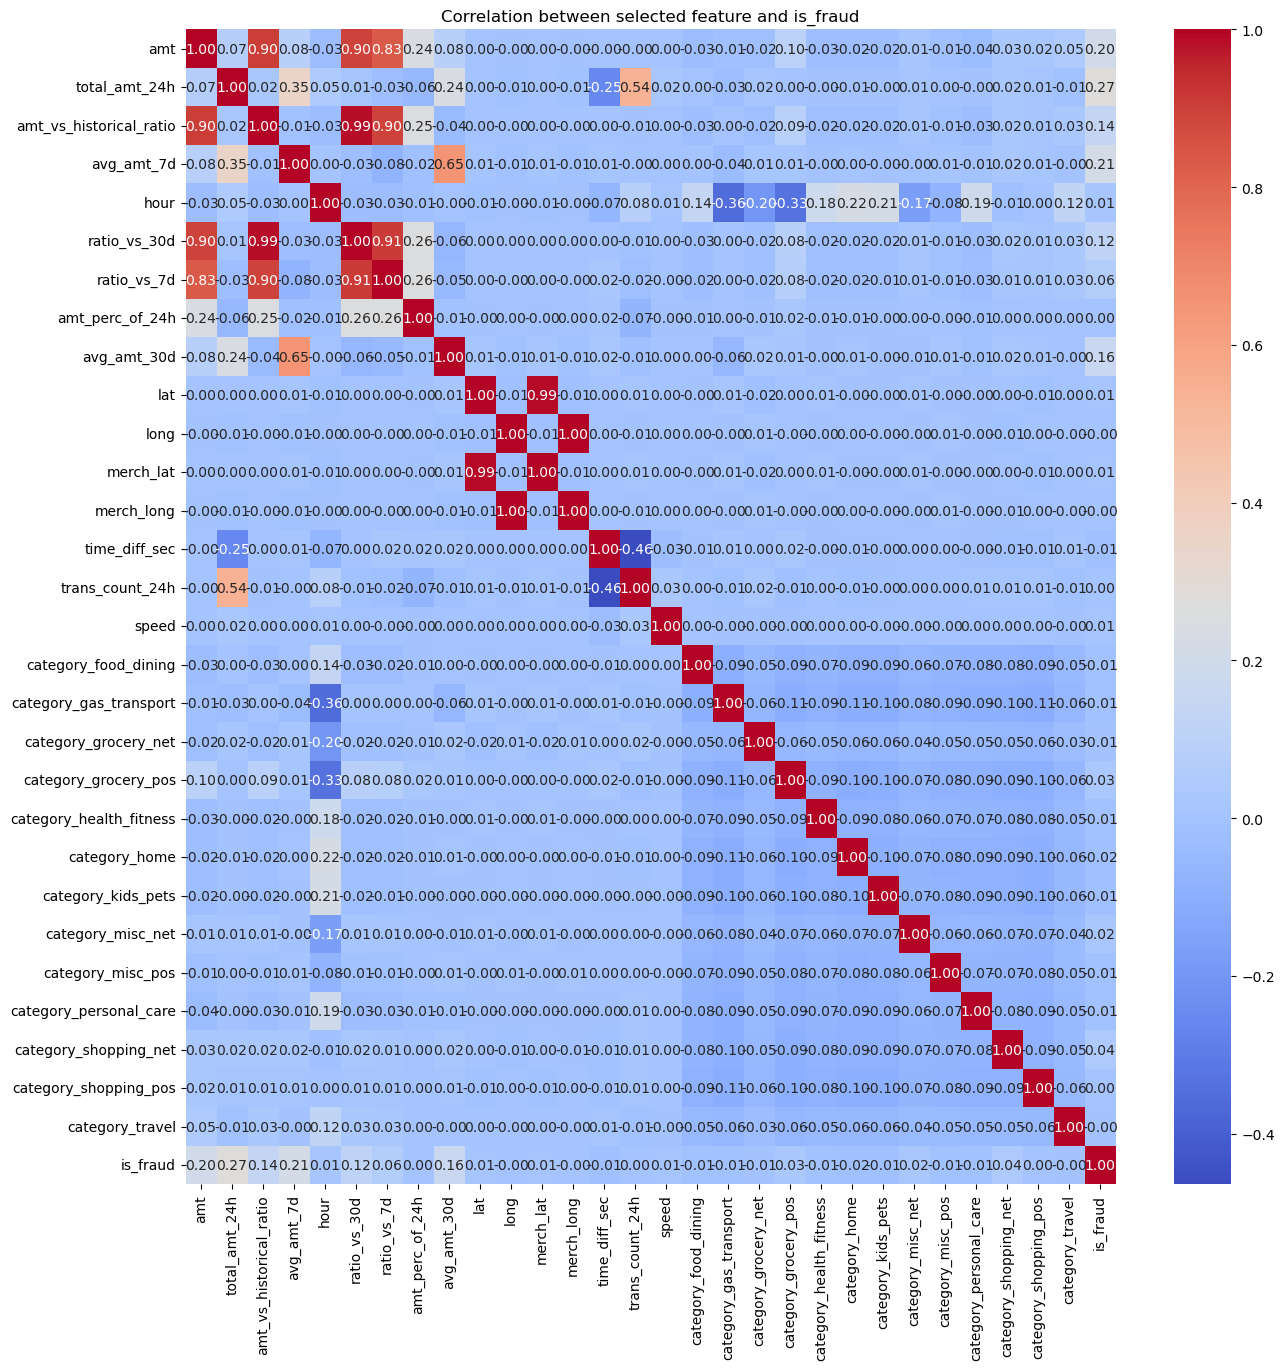

In [39]:
selected_df = X_train_selected.copy()
selected_df = pd.get_dummies(selected_df, columns=['category'], drop_first=True)
selected_df['is_fraud'] = y_train
plt.figure(figsize=(15, 15)) 
sns.heatmap(selected_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between selected feature and is_fraud')
plt.show()

In [83]:
selected_df.head(5)

,amt,total_amt_24h,amt_vs_historical_ratio,avg_amt_7d,hour,ratio_vs_30d,ratio_vs_7d,amt_perc_of_24h,avg_amt_30d,lat,...,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,is_fraud
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-06-21 12:14:25,2.86,0.0,1.0,0.0,12,0.0,0.0,0.0,0.0,33.9659,...,False,False,False,False,False,True,False,False,False,0
2013-06-21 12:14:33,29.84,0.0,1.0,0.0,12,0.0,0.0,0.0,0.0,40.3207,...,False,False,False,False,False,True,False,False,False,0
2013-06-21 12:14:53,41.28,0.0,1.0,0.0,12,0.0,0.0,0.0,0.0,40.6729,...,True,False,False,False,False,False,False,False,False,0
2013-06-21 12:15:15,60.05,0.0,1.0,0.0,12,0.0,0.0,0.0,0.0,28.5697,...,False,False,False,False,True,False,False,False,False,0
2013-06-21 12:15:17,3.19,0.0,1.0,0.0,12,0.0,0.0,0.0,0.0,44.2529,...,False,False,False,False,False,False,False,False,True,0


In [42]:
def cal_vif(X):
    X_vif = X.copy()
    if 'category' in X_vif.columns:
        X_vif = pd.get_dummies(X_vif, columns=['category'], drop_first=True)
    
    X_vif = X_vif.select_dtypes(include=['number'])
    X_vif = add_constant(X_vif, has_constant='add')
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                       for i in range(X_vif.shape[1])]
    
    vif_result = vif_data[vif_data["Feature"] != 'const'].sort_values(by="VIF", ascending=False)
    
    return vif_result


In [43]:
vif_df = cal_vif(X_train_selected)
print(vif_df)

                    Feature         VIF
11                     long  565.645987
13               merch_long  565.644268
10                      lat   77.809089
12                merch_lat   77.808164
6              ratio_vs_30d   49.390085
3   amt_vs_historical_ratio   45.321307
7               ratio_vs_7d    6.267323
1                       amt    6.129018
4                avg_amt_7d    1.999448
9               avg_amt_30d    1.884246
15          trans_count_24h    1.787810
2             total_amt_24h    1.731224
14            time_diff_sec    1.280714
8           amt_perc_of_24h    1.082780
5                      hour    1.009153
16                    speed    1.001546


In [44]:
X_train_drop= X_train_selected.drop(columns=['ratio_vs_30d','long','lat'])
vif_df = cal_vif(X_train_drop)
print(vif_df)

                    Feature       VIF
3   amt_vs_historical_ratio  9.324611
1                       amt  6.117060
6               ratio_vs_7d  5.415677
4                avg_amt_7d  1.993555
8               avg_amt_30d  1.843943
12          trans_count_24h  1.786880
2             total_amt_24h  1.728531
11            time_diff_sec  1.280686
7           amt_perc_of_24h  1.081371
5                      hour  1.009102
13                    speed  1.001542
9                 merch_lat  1.000625
10               merch_long  1.000344


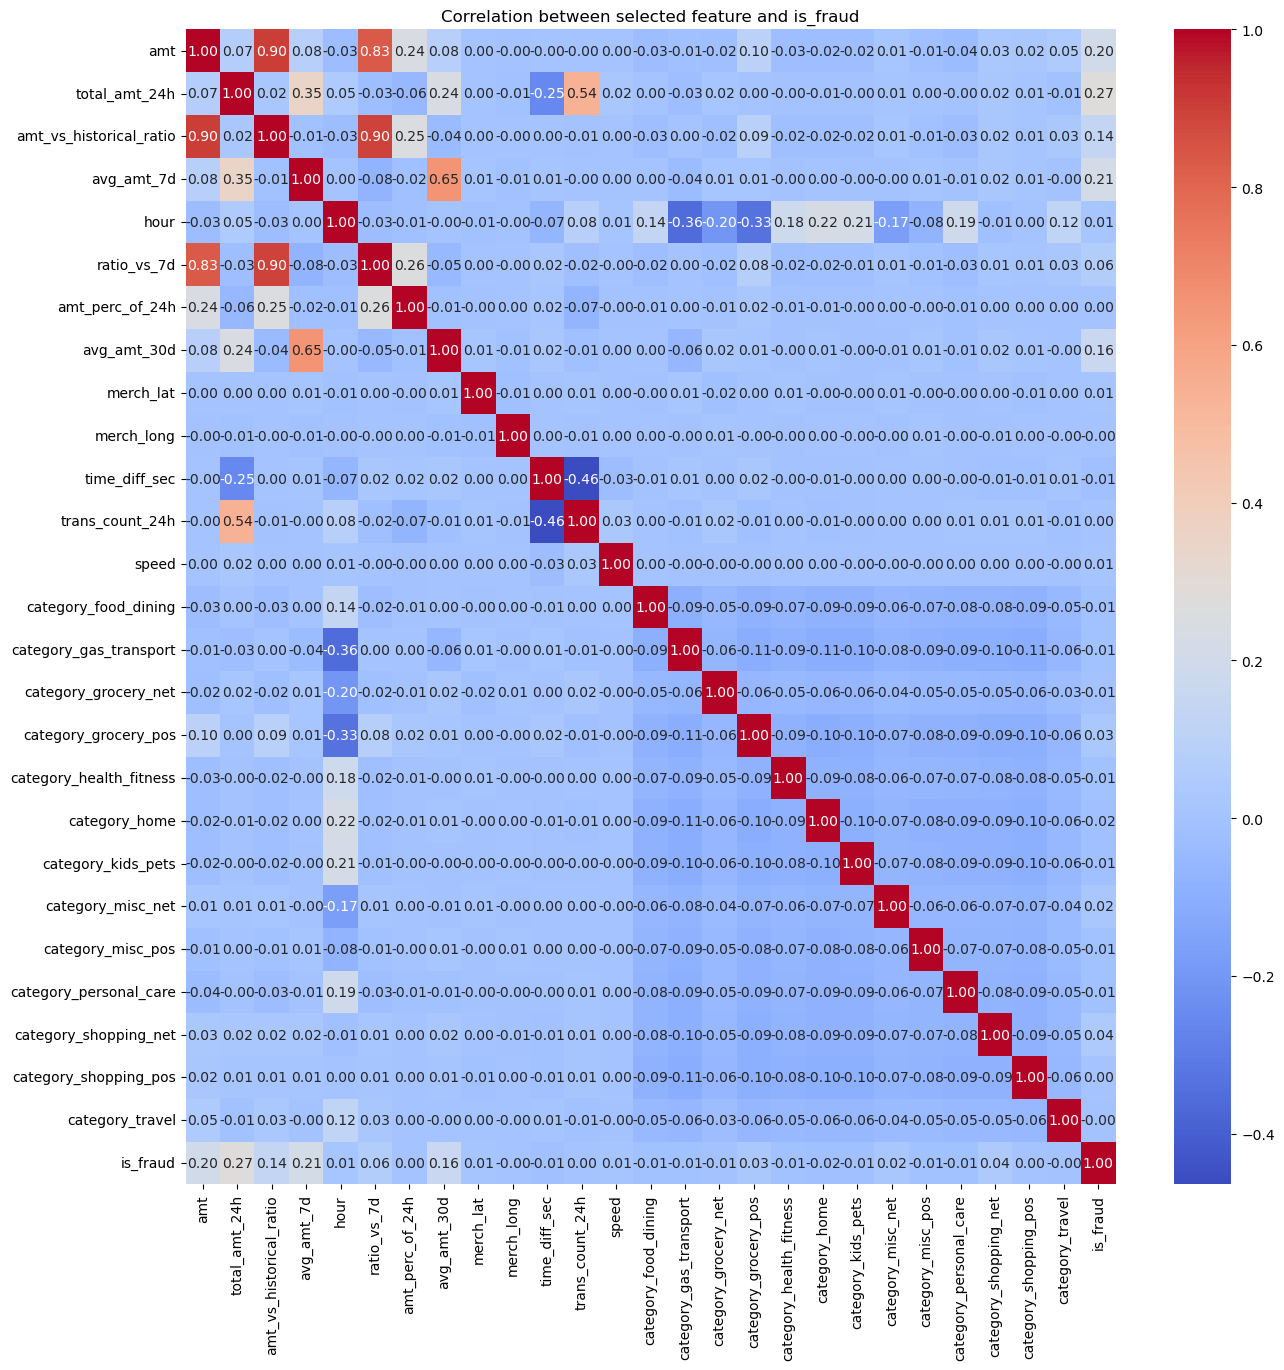

In [45]:
selected_df = X_train_drop.copy()
selected_df = pd.get_dummies(selected_df, columns=['category'], drop_first=True)
selected_df['is_fraud'] = y_train
plt.figure(figsize=(15, 15)) 
sns.heatmap(selected_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between selected feature and is_fraud')
plt.show()

In [24]:
# the core processor to encode and transform the selected feature
num_log_robust_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('robust', RobustScaler())
])

preprocessor_v2 = ColumnTransformer(
    transformers=[
        # ('merchant_enc', LeaveOneOutEncoder(sigma=0.05), ['merchant']), 
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['category']),
        ('num_log_robust', num_log_robust_pipe, ['amt', 'total_amt_24h', 'amt_vs_historical_ratio', 'avg_amt_7d', 
                                                 'ratio_vs_30d', 'ratio_vs_7d', 'avg_amt_30d', 'amt_perc_of_24h',
                                                 'time_diff_sec','speed']),
        ('num_robust', RobustScaler() ,['trans_count_24h']),
        ('num_std', StandardScaler(), ['lat', 'long', 'merch_lat', 'merch_long']),
        ('hour_sin', FunctionTransformer(sin_transformer, kw_args={'max_val': 24}),['hour']),
        ('hour_cos', FunctionTransformer(cos_transformer, kw_args={'max_val': 24}),['hour']),
    ],
    remainder='drop'
)

**Update preprocessor_v2 to deal with only selected features.**

# MODELING - LOGISTIC REGRESSION

In [38]:
# Use Logistic Classification  
# use random undersampling to eliminate some random data point of majority class, give a ratio to 1:10 
# use smote to oversampling to generate the minority class, use variety of ratio to choose the ratio work best with LC
# K-fold sampling = 3 to force the machine run 3 times for each ratio then return mean efficency score
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}
ratios = [0.2, 0.3, 0.5]
tscv = TimeSeriesSplit(n_splits=3)

print(f"Start running Logistic Classification on {X_train_selected.shape[1]} features...")
print("-" * 50)

for ratio in ratios:
    lr_pipe = Pipeline([
        ('prep', preprocessor_v2),
        ('under', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    results = cross_validate(lr_pipe, X_train_selected, y_train, cv=tscv, scoring=scoring, n_jobs=1)
    print(f"SMOTE Ratio {ratio}:")
    print(f"  > Mean F1 Score: {results['test_f1'].mean():.4f}")
    print(f"  > Mean PR-AUC:   {results['test_pr_auc'].mean():.4f}")
    print("-" * 30)

Start running Logistic Classification on 17 features...
--------------------------------------------------
SMOTE Ratio 0.2:
  > Mean F1 Score: 0.0899
  > Mean PR-AUC:   0.5224
------------------------------
SMOTE Ratio 0.3:
  > Mean F1 Score: 0.0898
  > Mean PR-AUC:   0.5287
------------------------------
SMOTE Ratio 0.5:
  > Mean F1 Score: 0.0913
  > Mean PR-AUC:   0.5236
------------------------------


In [41]:
# Use Logistic Classification  
# K-fold sampling = 3 to force the machine run 3 times for each ratio then return mean efficency score
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}
tscv = TimeSeriesSplit(n_splits=3)

print(f"Start running Logistic Classification on {X_train_selected.shape[1]} features...")
print("-" * 50)

lr_pipe = Pipeline([
    ('prep', preprocessor_v2),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
results = cross_validate(lr_pipe, X_train_selected, y_train, cv=tscv, scoring=scoring, n_jobs=1)
print(f"  > Mean F1 Score: {results['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results['test_pr_auc'].mean():.4f}")
print("-" * 30)

Start running Logistic Classification on 17 features...
--------------------------------------------------
  > Mean F1 Score: 0.0860
  > Mean PR-AUC:   0.4982
------------------------------


**Observation:** To evaluate why Logistic Regression underperformed with the 17 selected features, I tested two different imbalance-handling approaches across different feature sets. Since the initial results were unsatisfactory, I decided to re-train the model on the original dataset to determine if the poor performance was caused by information loss during feature selection or by the preceding transformation and engineering steps.

In [39]:
# try to fit on the most final train set withour any selection / transformation
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}
ratios = [0.2, 0.3, 0.5]

print(f"Start running Logistic Classification on {X_train_final.shape[1]} features...")
print("-" * 50)

for ratio in ratios:
    lr_pipe_2 = Pipeline([
        ('under', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    results_2 = cross_validate(lr_pipe_2, X_train_final, y_train, cv=tscv, scoring=scoring, n_jobs=1)

        
    print(f"SMOTE Ratio {ratio}:")
    print(f"  > Mean F1 Score: {results_2['test_f1'].mean():.4f}")
    print(f"  > Mean PR-AUC:   {results_2['test_pr_auc'].mean():.4f}")
    print("-" * 30)

Start running Logistic Classification on 53 features...
--------------------------------------------------
SMOTE Ratio 0.2:
  > Mean F1 Score: 0.0992
  > Mean PR-AUC:   0.4694
------------------------------
SMOTE Ratio 0.3:
  > Mean F1 Score: 0.1044
  > Mean PR-AUC:   0.4733
------------------------------
SMOTE Ratio 0.5:
  > Mean F1 Score: 0.1048
  > Mean PR-AUC:   0.4649
------------------------------


In [40]:
# try to fit on the most final train set withour any selection / transformation
# without sampling method
print(f"Start running Logistic Classification without hybrid sampling on {X_train_final.shape[1]} features...")
print("-" * 50)

lr_pipe_4 = Pipeline([
    ('lr', LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000, random_state=42))
])
results_2 = cross_validate(lr_pipe_4, X_train_final, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
print(f"  > Mean F1 Score: {results_2['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results_2['test_pr_auc'].mean():.4f}")
print("-" * 30)

Start running Logistic Classification without hybrid sampling on 53 features...
--------------------------------------------------
  > Mean F1 Score: 0.1010
  > Mean PR-AUC:   0.4233
------------------------------


**Observation:** The performance of Logistic Regression (LR) on the original dataset remained poor, confirming that the issue was not caused by information loss during feature selection, but rather by the inherent limitations of the LR model on this specific data. Despite this, I will proceed with the reduced set of 16 features to mitigate multicollinearity, ensuring that the model's coefficients remain stable and its performance as reliable as possible for this algorithm.

In [33]:
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ('num_log_robust', num_log_robust_pipe, [
            'total_amt_24h', 'amt_vs_historical_ratio', 'avg_amt_7d', 
            'amt', 'ratio_vs_7d', 'avg_amt_30d', 'amt_perc_of_24h',
            'time_diff_sec', 'speed'
        ]),
        ('num_robust', RobustScaler(), ['trans_count_24h']),
        ('num_std', StandardScaler(), ['merch_lat', 'merch_long']), 
        ('hour_sin', FunctionTransformer(sin_transformer, kw_args={'max_val': 24}), ['hour']),
        ('hour_cos', FunctionTransformer(cos_transformer, kw_args={'max_val': 24}), ['hour']),
    ],
    remainder='drop'
)

In [49]:
# Use Logistic Classification  
# K-fold sampling = 3 to force the machine run 3 times for each ratio then return mean efficency score
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}
print(f"Start running Logistic Classification on {X_train_drop.shape[1]} features...")
print("-" * 50)

lr_pipe_4 = Pipeline([
    ('prep', preprocessor_reduced),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
results_4 = cross_validate(lr_pipe_4, X_train_drop, y_train, cv=tscv, scoring=scoring, n_jobs=1)
print(f"  > Mean F1 Score: {results_4['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results_4['test_pr_auc'].mean():.4f}")
print("-" * 30)

Start running Logistic Classification on 14 features...
--------------------------------------------------
  > Mean F1 Score: 0.0865
  > Mean PR-AUC:   0.5514
------------------------------


In [48]:
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}
ratios = [0.2, 0.3, 0.5]

print(f"Start running Logistic Classification on {X_train_drop.shape[1]} features...")
print("-" * 50)

for ratio in ratios:
    lr_pipe_3 = Pipeline([
        ('prep', preprocessor_reduced),
        ('under', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    results_3 = cross_validate(lr_pipe_3, X_train_drop, y_train, cv=tscv, scoring=scoring, n_jobs=1)

        
    print(f"SMOTE Ratio {ratio}:")
    print(f"  > Mean F1 Score: {results_3['test_f1'].mean():.4f}")
    print(f"  > Mean PR-AUC:   {results_3['test_pr_auc'].mean():.4f}")
    print("-" * 30)

Start running Logistic Classification on 14 features...
--------------------------------------------------
SMOTE Ratio 0.2:
  > Mean F1 Score: 0.0866
  > Mean PR-AUC:   0.5556
------------------------------
SMOTE Ratio 0.3:
  > Mean F1 Score: 0.0860
  > Mean PR-AUC:   0.5551
------------------------------
SMOTE Ratio 0.5:
  > Mean F1 Score: 0.0875
  > Mean PR-AUC:   0.5528
------------------------------


**Observation:** Since the performance remained consistently low across several models, I chose the 14-feature model—integrated with SMOTE (0.2), undersampling, and class weights—for the threshold tuning stage. This streamlined model was selected because it delivers competitive results compared to more complex configurations, offering a better balance between efficiency and predictive power.

In [34]:
 lr_pipe_4 = Pipeline([
        ('prep', preprocessor_reduced),
        ('under', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
        ('smote', SMOTE(sampling_strategy=0.2, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])

In [46]:
tscv = TimeSeriesSplit(n_splits=3)

all_y_val_4 = []
all_y_probs_4 = []

for train_index, val_index in tscv.split(X_train_drop):
    # Split dataset into train + validation
    X_t, X_v = X_train_drop.iloc[train_index], X_train_drop.iloc[val_index]
    y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Training the model on training set
    lr_pipe_4.fit(X_t, y_t)
    
    probs_4 = lr_pipe_4.predict_proba(X_v)[:, 1]
    
    all_y_val_4.extend(y_v)
    all_y_probs_4.extend(probs_4)

all_y_val_4 = np.array(all_y_val_4)
all_y_probs_4 = np.array(all_y_probs_4)

precision_4, recall_4, thresholds_4 = precision_recall_curve(all_y_val_4, all_y_probs_4)
f1_scores_4 = 2 * (precision_4 * recall_4) / (precision_4 + recall_4 + 1e-10)

best_threshold_4 = thresholds_4[np.argmax(f1_scores_4)]

print(f"Best threshold: {best_threshold_4:.4f}")
print(f"Highest F1 Score: {np.max(f1_scores_4):.4f}")

Best threshold: 0.9815
Highest F1 Score: 0.5697


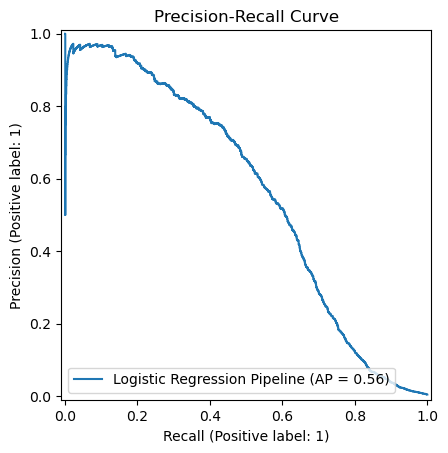

In [47]:
display = PrecisionRecallDisplay.from_predictions(
    all_y_val_4, all_y_probs_4, name="Logistic Regression Pipeline"
)
_ = display.ax_.set_title("Precision-Recall Curve")

**Observation:** The optimal threshold of 0.9815, combined with the steep slope of the PR-AUC curve, further confirms that Logistic Regression is struggling with this dataset. Specifically, a threshold above 0.9 is impractical for real-world deployment, as it requires the model to be over 90% certain before flagging a transaction as fraudulent. This lack of sensitivity suggests that the model cannot effectively distinguish between classes at lower probability levels, resulting in a high risk of missing sophisticated fraud patterns.

# RESULT + EVALUATION - LOGISTIC REGRESSION

In [48]:
lr_pipe_4.fit(X_train, y_train)
y_pred_lr = lr_pipe_4.predict(X_test)

print("---RESULT ON TEST SET---")
print(classification_report(y_test, y_pred_lr))

---RESULT ON TEST SET---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    110960
           1       0.02      0.80      0.04       184

    accuracy                           0.94    111144
   macro avg       0.51      0.87      0.51    111144
weighted avg       1.00      0.94      0.97    111144



In [49]:
y_test_probs_lr = lr_pipe_4.predict_proba(X_test)[:, 1]
y_test_pred_lr = (y_test_probs_lr >= best_threshold_4).astype(int)

print(classification_report(y_test, y_test_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110960
           1       0.33      0.42      0.37       184

    accuracy                           1.00    111144
   macro avg       0.66      0.71      0.68    111144
weighted avg       1.00      1.00      1.00    111144



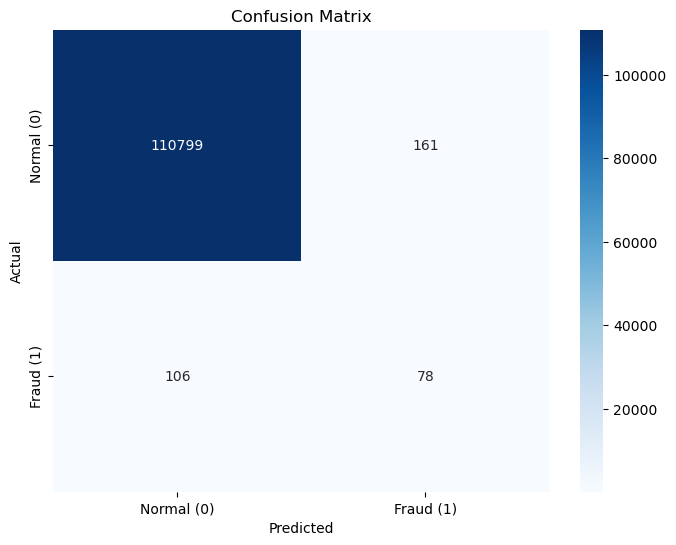

In [50]:
cm = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()

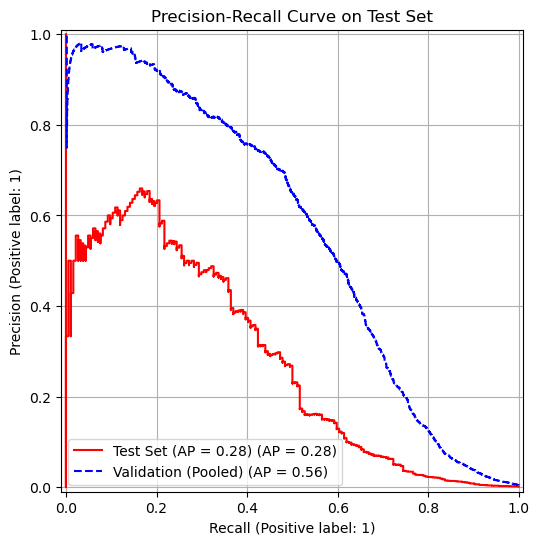

In [55]:
ap_test_lr = average_precision_score(y_test, y_test_probs_lr)

fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs_lr, name=f"Test Set (AP = {ap_test_lr:.2f})", ax=ax, color='red'
)

PrecisionRecallDisplay.from_predictions(all_y_val_3, all_y_probs_3, name="Validation (Pooled)", ax=ax, color='blue', linestyle='--')

ax.set_title("Precision-Recall Curve on Test Set")
ax.grid(True)
plt.show()

**Observation:** The PR-AUC comparison between the validation and test sets highlights a significant drop in generalization; the fraud patterns learned during training fail to effectively translate to unseen data. Furthermore, the classification results at both default and optimal thresholds reveal a severe trade-off. To achieve even a 42% recall, the model is forced to sacrifice nearly 70% of its precision, demonstrating that the model struggles to maintain accuracy while attempting to capture fraudulent transactions.

# MODELING - RANDOM FOREST

In [89]:
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}

rf_pipe = Pipeline([
    ('prep', preprocessor_v2),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,        
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1         
    ))
])

results = cross_validate(rf_pipe, X_train_selected, y_train, cv=tscv, scoring=scoring, n_jobs=-1)

print(f"Random Forest Result:")
print(f"  > Mean F1 Score: {results['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results['test_pr_auc'].mean():.4f}")

Random Forest Result:
  > Mean F1 Score: 0.5957
  > Mean PR-AUC:   0.7858


In [91]:
rf_pipe_2 = Pipeline([
    ('prep', preprocessor_v2),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,        
        class_weight='balanced_subsample', 
        random_state=42, 
        n_jobs=-1         
    ))
])

results_bs = cross_validate(rf_pipe_2, X_train_selected, y_train, cv=3, scoring=scoring, n_jobs=-1)

print(f"Random Forest Result:")
print(f"  > Mean F1 Score: {results_bs['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results_bs['test_pr_auc'].mean():.4f}")

Random Forest Result:
  > Mean F1 Score: 0.5251
  > Mean PR-AUC:   0.7745


**Observation:** A comparative evaluation between class_weight='balanced' and 'balanced_subsample' revealed no significant performance gain from the latter. This indicates that the global class proportions are sufficiently representative across bootstrap samples, making the dynamic re-calculation of weights unnecessary. Consequently, the standard 'balanced' approach was adopted for its computational efficiency and stability.

In [90]:
param_distributions = { 
    'rf__max_depth': [10, 20, 30, None], 
    'rf__min_samples_leaf': [4, 10], 
    'rf__min_samples_split': [2, 5, 10], 
    'rf__n_estimators': [100] 
}

scoring_metrics = { 'F1': 'f1', 'PR_AUC': 'average_precision' }

random_search = RandomizedSearchCV( 
    estimator=rf_pipe, 
    param_distributions=param_distributions,
    n_iter=5, 
    cv=tscv, 
    scoring=scoring_metrics,
    refit='F1', 
    n_jobs=1, 
    verbose=2,
    random_state=42 
)

random_search.fit(X_train_selected, y_train)

results_df = pd.DataFrame(random_search.cv_results_)

important_columns = [ 'param_rf__max_depth', 'param_rf__min_samples_leaf', 'mean_test_F1', 'mean_test_PR_AUC' ] 
print(results_df[important_columns].sort_values(by='mean_test_F1', ascending=False))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END rf__max_depth=20, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=100; total time=  22.0s
[CV] END rf__max_depth=20, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=100; total time=  44.8s
[CV] END rf__max_depth=20, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=100; total time= 1.3min
[CV] END rf__max_depth=30, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time=  22.1s
[CV] END rf__max_depth=30, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time=  44.1s
[CV] END rf__max_depth=30, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time= 1.4min
[CV] END rf__max_depth=10, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=100; total time=  17.7s
[CV] END rf__max_depth=10, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=100; total time=  43.0

In [92]:
# check the score of the whole training set by using the best model
best_model = random_search.best_estimator_
train_f1 = f1_score(y_train, best_model.predict(X_train_selected))
print(f"F1 Train: {train_f1:.4f}")
print(f"F1 Test (Validation): {random_search.best_score_:.4f}")

F1 Train: 0.9074
F1 Test (Validation): 0.7948


**Observation:** The best model show a overfitting problem while the F1 score on validation test is 0.7 while on the Test set up to 0.9. Therefore, next I will examine the second highest score

In [109]:
rf_pipe_3_1 = Pipeline([
    ('prep', preprocessor_v2),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=20,
        min_samples_leaf = 10,
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [110]:
rf_pipe_3_1.fit(X_train_selected, y_train)
y_train_pred_3_1 = rf_pipe_3_1.predict(X_train_selected)

F1 Train: 0.8958


In [111]:
train_f1_3_1 = f1_score(y_train, y_train_pred_3_1)
print(f"F1 Train: {train_f1_3_1:.4f}")

F1 Train: 0.8904


In [94]:
rf_pipe_3 = Pipeline([
    ('prep', preprocessor_v2),
    ('rf', RandomForestClassifier(
        n_estimators=300, 
        max_depth=20,
        min_samples_leaf = 10,
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [95]:
rf_pipe_3.fit(X_train_selected, y_train)
y_train_pred = rf_pipe_3.predict(X_train_selected)
train_f1 = f1_score(y_train, y_train_pred)

In [96]:
print(f"F1 Train: {train_f1:.4f}")

F1 Train: 0.8958


**Observation:** The second model still show overfitting problem (0.8904 vs0.7914) Therefore, seconde random search will conduct with restrict lower on parameters

In [97]:
param_distributions = {
    'rf__max_depth': [10, 12, 15], 
    'rf__min_samples_leaf': [4, 10], 
    'rf__n_estimators': [100]
}

random_search_2 = RandomizedSearchCV(
    estimator=rf_pipe_3, 
    param_distributions=param_distributions, 
    n_iter=4, 
    cv=tscv, 
    scoring=scoring_metrics,  
    refit='F1',
    n_jobs=1,
    verbose=2,
    random_state=42
)

random_search_2.fit(X_train_selected, y_train)

results_df_2 = pd.DataFrame(random_search_2.cv_results_)

important_columns = [ 'param_rf__max_depth', 'param_rf__min_samples_leaf', 'mean_test_F1', 'mean_test_PR_AUC' ] 
print(results_df_2[important_columns].sort_values(by='mean_test_F1', ascending=False))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END rf__max_depth=10, rf__min_samples_leaf=4, rf__n_estimators=100; total time= 1.0min
[CV] END rf__max_depth=10, rf__min_samples_leaf=4, rf__n_estimators=100; total time= 1.9min
[CV] END rf__max_depth=10, rf__min_samples_leaf=4, rf__n_estimators=100; total time= 3.2min
[CV] END rf__max_depth=10, rf__min_samples_leaf=10, rf__n_estimators=100; total time=  56.4s
[CV] END rf__max_depth=10, rf__min_samples_leaf=10, rf__n_estimators=100; total time= 2.1min
[CV] END rf__max_depth=10, rf__min_samples_leaf=10, rf__n_estimators=100; total time= 3.4min
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__n_estimators=100; total time=  51.8s
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__n_estimators=100; total time= 1.8min
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__n_estimators=100; total time= 3.2min
[CV] END rf__max_depth=12, rf__min_samples_leaf=4, rf__n_estimators=100; total time=  42.3s
[CV] END rf__m

In [57]:
rf_pipe_4 = Pipeline([
    ('prep', preprocessor_v2),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=15,      
        min_samples_leaf = 10,
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [113]:
rf_pipe_4.fit(X_train_selected, y_train)
y_train_pred_4 = rf_pipe_4.predict(X_train_selected)
train_f1_2 = f1_score(y_train, y_train_pred_4)
print(f"F1 Train: {train_f1_2:.4f}")

F1 Train: 0.8250


**After the whole process, model rf_pipe_4 was chosent to present for the RF model using cost weighted approach**  
Next step will do the same to the RF model intergrate hybrid sampling + cost-weighted

In [101]:
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=42)
smote = SMOTE(sampling_strategy=0.1, random_state=42)

rf_pipe_5 = Pipeline([
    ('prep', preprocessor_v2),
    ('undersample', rus), 
    ('smote', smote),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,      
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [103]:
param_distributions = {
    'rf__max_depth': [12, 15, 20], 
    'rf__min_samples_leaf': [4, 10], 
    'rf__min_samples_split': [2, 5, 10], 
    'rf__n_estimators': [100] 
}

scoring_metrics = { 'F1': 'f1', 'PR_AUC': 'average_precision' }

random_search_3 = RandomizedSearchCV( 
    estimator=rf_pipe_5, 
    param_distributions=param_distributions,
    n_iter=5, 
    cv=tscv, 
    scoring=scoring_metrics,
    refit='F1', 
    n_jobs=1, 
    verbose=2,
    random_state=100 
)



random_search_3.fit(X_train_selected, y_train)

results_df_3 = pd.DataFrame(random_search_3.cv_results_)

important_columns = [ 'param_rf__max_depth', 'param_rf__min_samples_leaf', 'mean_test_F1', 'mean_test_PR_AUC' ] 
print(results_df_3[important_columns].sort_values(by='mean_test_F1', ascending=False))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  22.6s
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  56.0s
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__min_samples_split=2, rf__n_estimators=100; total time= 2.0min
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__min_samples_split=10, rf__n_estimators=100; total time=  20.9s
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__min_samples_split=10, rf__n_estimators=100; total time= 1.2min
[CV] END rf__max_depth=15, rf__min_samples_leaf=10, rf__min_samples_split=10, rf__n_estimators=100; total time= 1.6min
[CV] END rf__max_depth=20, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time=  21.0s
[CV] END rf__max_depth=20, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time= 

In [104]:
# check the score of the whole training set by using the best model
best_model_2 = random_search_3.best_estimator_
train_f1_2 = f1_score(y_train, best_model_2.predict(X_train_selected))
print(f"F1 Train: {train_f1_2:.4f}")
print(f"F1 Test (Validation): {random_search_3.best_score_:.4f}")

F1 Train: 0.8537
F1 Test (Validation): 0.7693


In [25]:
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=42)
smote = SMOTE(sampling_strategy=0.1, random_state=42)

rf_pipe_6 = Pipeline([
    ('prep', preprocessor_v2),
    ('undersample', rus), 
    ('smote', smote),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        min_samples_leaf = 4,
        max_depth=20,      
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

**Threshold Tuning**  
rf_pipe_6 an rf_pipe_4 were selected to the threshold tuning step

In [58]:
tscv = TimeSeriesSplit(n_splits=3)

all_y_val = []
all_y_probs = []

for train_index, val_index in tscv.split(X_train_selected):
    # Split dataset into train + validation
    X_t, X_v = X_train_selected.iloc[train_index], X_train.iloc[val_index]
    y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Training the model on training set
    rf_pipe_4.fit(X_t, y_t)
    
    probs = rf_pipe_4.predict_proba(X_v)[:, 1]
    
    all_y_val.extend(y_v)
    all_y_probs.extend(probs)

all_y_val = np.array(all_y_val)
all_y_probs = np.array(all_y_probs)

precision, recall, thresholds = precision_recall_curve(all_y_val, all_y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Highest F1 Score: {np.max(f1_scores):.4f}")

Best threshold: 0.5690
Highest F1 Score: 0.7855


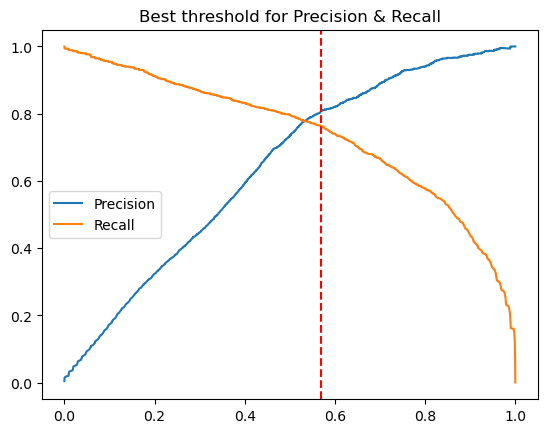

In [59]:
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(best_threshold, color='red', linestyle='--')
plt.legend()
plt.title('Best threshold for Precision & Recall')
plt.show()

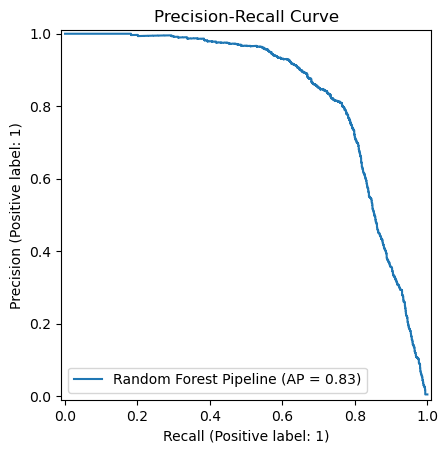

In [60]:
display = PrecisionRecallDisplay.from_predictions(
    all_y_val, all_y_probs, name="Random Forest Pipeline"
)
_ = display.ax_.set_title("Precision-Recall Curve")

In [70]:
tscv = TimeSeriesSplit(n_splits=3)

all_y_val_2 = []
all_y_probs_2 = []

for train_index, val_index in tscv.split(X_train_selected):
    # Split dataset into train + validation
    X_t, X_v = X_train_selected.iloc[train_index], X_train.iloc[val_index]
    y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Training the model on training set
    rf_pipe_6.fit(X_t, y_t)
    
    probs = rf_pipe_6.predict_proba(X_v)[:, 1]
    
    all_y_val_2.extend(y_v)
    all_y_probs_2.extend(probs)

all_y_val_2 = np.array(all_y_val_2)
all_y_probs_2 = np.array(all_y_probs_2)

precision_2, recall_2, thresholds_2 = precision_recall_curve(all_y_val_2, all_y_probs_2)
f1_scores_2 = 2 * (precision_2 * recall_2) / (precision_2 + recall_2 + 1e-10)

In [71]:
best_threshold_2 = thresholds_2[np.argmax(f1_scores_2)]

print(f"Best threshold: {best_threshold_2:.4f}")
print(f"Highest F1 Score: {np.max(f1_scores_2):.4f}")

Best threshold: 0.6684
Highest F1 Score: 0.8167


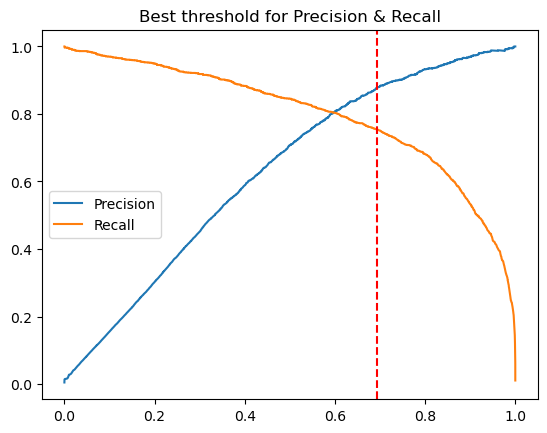

In [119]:
plt.plot(thresholds_2, precision_2[:-1], label='Precision')
plt.plot(thresholds_2, recall_2[:-1], label='Recall')
plt.axvline(best_threshold_2, color='red', linestyle='--')
plt.legend()
plt.title('Best threshold for Precision & Recall')
plt.show()

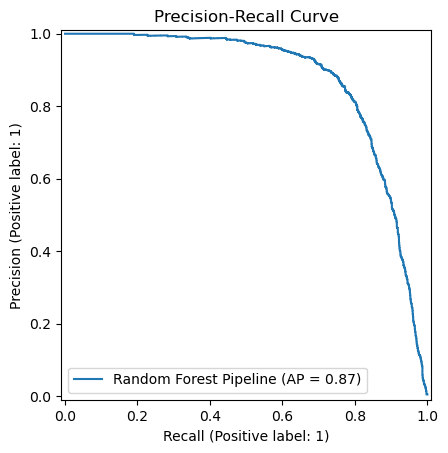

In [120]:
display = PrecisionRecallDisplay.from_predictions(
    all_y_val_2, all_y_probs_2, name="Random Forest Pipeline"
)
_ = display.ax_.set_title("Precision-Recall Curve")

# RESULT + EVALUATION - RANDOM FOREST

In [121]:
rf_pipe_4.fit(X_train, y_train)
y_pred = rf_pipe_4.predict(X_test)

print("---RESULT ON TEST SET---")
print(classification_report(y_test, y_pred))

---RESULT ON TEST SET---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110960
           1       0.42      0.80      0.55       184

    accuracy                           1.00    111144
   macro avg       0.71      0.90      0.77    111144
weighted avg       1.00      1.00      1.00    111144



In [122]:
y_test_probs = rf_pipe_4.predict_proba(X_test)[:, 1]
y_test_pred_custom = (y_test_probs >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110960
           1       0.55      0.77      0.64       184

    accuracy                           1.00    111144
   macro avg       0.78      0.89      0.82    111144
weighted avg       1.00      1.00      1.00    111144



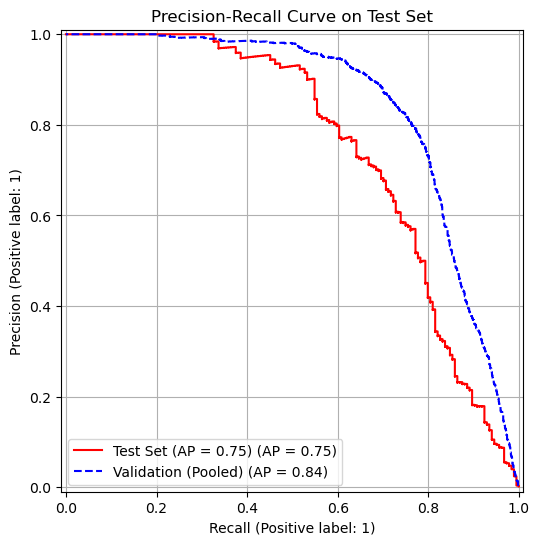

In [125]:
ap_test = average_precision_score(y_test, y_test_probs)

fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs, name=f"Test Set (AP = {ap_test:.2f})", ax=ax, color='red'
)

PrecisionRecallDisplay.from_predictions(all_y_val, all_y_probs, name="Validation (Pooled)", ax=ax, color='blue', linestyle='--')

ax.set_title("Precision-Recall Curve on Test Set")
ax.grid(True)
plt.show()

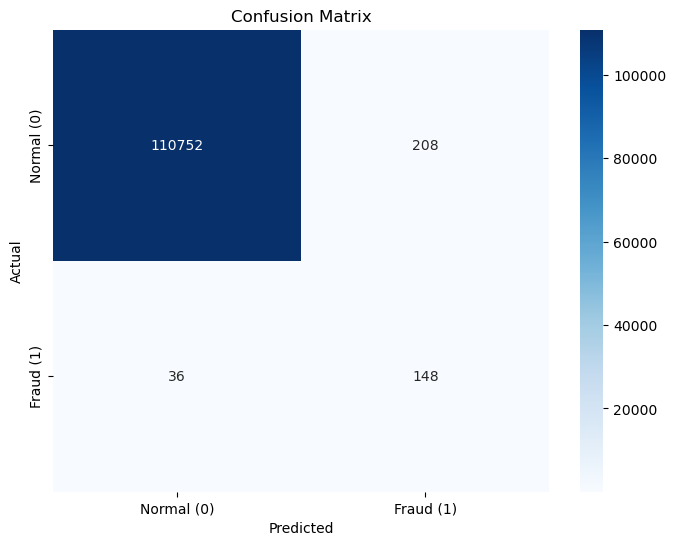

In [128]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()

In [26]:
rf_pipe_6.fit(X_train, y_train)
y_pred_2 = rf_pipe_6.predict(X_test)

print("---RESULT ON TEST SET---")
print(classification_report(y_test, y_pred_2))

---RESULT ON TEST SET---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110960
           1       0.42      0.86      0.56       184

    accuracy                           1.00    111144
   macro avg       0.71      0.93      0.78    111144
weighted avg       1.00      1.00      1.00    111144



In [32]:
root_dir = Path(__file__).resolve().parent.parent if "__file__" in locals() else Path().resolve().parent

models_dir = root_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "fraud_detection_pipeline.joblib"

joblib.dump(rf_pipe_6, model_path)
print(f"Model saved successfully at: {model_path}")

Model saved successfully at: E:\[2025][DataAnalytics] Class Materials\[1] Machine Learning\CA\Credit-Card-Fraud-Detection\models\fraud_detection_pipeline.joblib


In [73]:
y_test_probs_2 = rf_pipe_6.predict_proba(X_test)[:, 1]
y_test_pred_custom_2 = (y_test_probs_2 >= best_threshold_2).astype(int)

print(classification_report(y_test, y_test_pred_custom_2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110960
           1       0.69      0.74      0.71       184

    accuracy                           1.00    111144
   macro avg       0.84      0.87      0.86    111144
weighted avg       1.00      1.00      1.00    111144



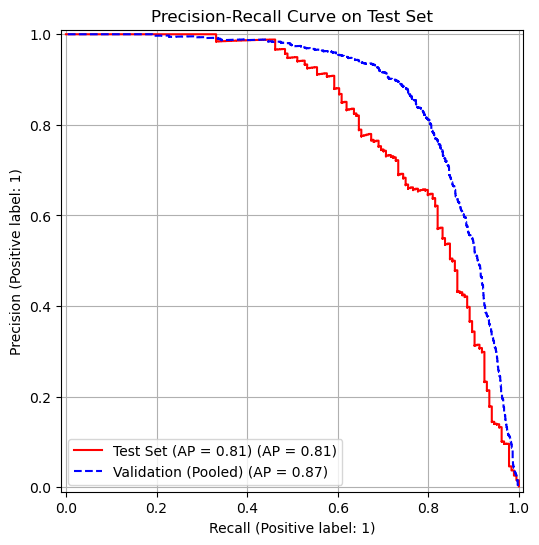

In [131]:
ap_test_2 = average_precision_score(y_test, y_test_probs_2)

fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs_2, name=f"Test Set (AP = {ap_test_2:.2f})", ax=ax, color='red'
)

PrecisionRecallDisplay.from_predictions(all_y_val_2, all_y_probs_2, name="Validation (Pooled)", ax=ax, color='blue', linestyle='--')

ax.set_title("Precision-Recall Curve on Test Set")
ax.grid(True)
plt.show()

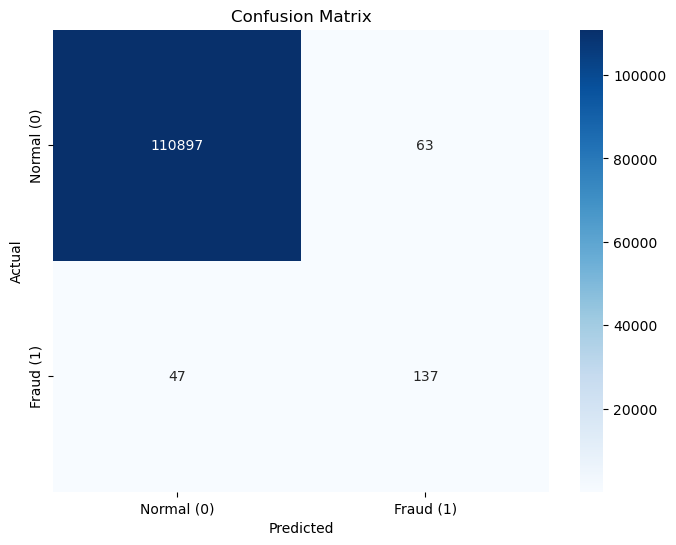

In [72]:
cm = confusion_matrix(y_test, y_test_pred_custom_2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()

[1]: https://distancia.readthedocs.io/en/latest/Haversine.html